# Exploratory Data Analysis — ERA5 Reanalysis for Larissa (1990–2025)

**Source file:** `data/larissa_era5_historical.csv`, built from raw per-year ERA5 `.nc` downloads
(`larissa_era5_{year}.nc`, 1990–2025) via the CDS API and merged into a single CSV by the conversion cell
below. The CSV already exists in this repo, so the conversion cell detects it and skips; the original
CDS-download step (`cdsapi.Client().retrieve(...)`, one call per year) ran once outside this notebook and
isn't reproduced here. Those intermediate per-year NetCDF files are not retained after the CSV is written,
unlike Seville's combined `.nc` twin — so there is no NetCDF file to peek at later in this notebook.

**Bounding box:** `area = [39.8, 22.2, 39.4, 22.7]` (N, W, S, E) around Larissa, Thessaly, Greece — returns a
**2 × 2 grid**: latitudes 39.50 / 39.75 °N × longitudes 22.25 / 22.50 °E

**Temporal coverage:** 1990-01-01 00:00 → 2025-12-31 18:00 UTC, at 00, 06, 12, 18 UTC

## Column dictionary

| Column | Meaning | Units | Notes |
|---|---|---|---|
| `valid_time` | Timestamp of the observation | datetime | Requested 00:00, 06:00, 12:00, 18:00 — presence of all four confirms the request worked |
| `latitude` | Grid point latitude | degrees | 2 latitude points inside the bounding box: 39.50, 39.75 |
| `longitude` | Grid point longitude | degrees | 2 longitude points: 22.25, 22.50 |
| `tp` | Total precipitation | **meters** | Hourly accumulation — a value like 0.00003 m = 0.03 mm is a trace amount, *not* zero. Multiply by 1000 to get mm |
| `t2m` | 2 m air temperature | Kelvin | e.g. 277.6 K |
| `u10` | 10 m wind, east–west component | m/s | Positive = blowing eastward |
| `v10` | 10 m wind, north–south component | m/s | Positive = blowing northward. Combine with `u10` via √(u10² + v10²) for wind speed |
| `d2m` | 2 m dewpoint temperature | Kelvin | Used together with `t2m` to derive relative humidity |
| `t2m_celsius` | Temperature converted to °C | °C | Already converted when the CSV was built above |
| `d2m_celsius` | Dewpoint converted to °C | °C | Already converted when the CSV was built above |
| `number`, `expver` | ensemble member / experiment version | — | Constants in this extraction; dropped in section 2 |

**Derived in this notebook**

| Column | Meaning | Units |
|---|---|---|
| `precip_mm` | `tp` × 1000 | mm |
| `precip_mm_scaled` | `precip_mm` × 6 — see section 3.2 | mm |
| `rh_percent` | Relative humidity, Magnus formula | % |
| `wind_speed` | √(u10² + v10²) | m/s |
| `wind_dir` | Direction the wind blows *from* | degrees |
| `heat_index_c` | NWS heat index | °C |
| `dewpoint_depression_c` | `t2m_celsius` − `d2m_celsius`, a dryness proxy | °C |

## Roadmap

This follows the same procedure used for the Seville ERA5 EDA (`seville_era5_eda.ipynb`), applied to Larissa:

0. Data acquisition — download the raw ERA5 NetCDF and convert to CSV (already done above)
1. Setup — dependency check, imports, load
2. Data quality audit — completeness, duplicates, constants, time regularity
3. Unit conversions and derived variables
4. Spatial variation across the 2 × 2 grid
5. **Averaging the four grid points** → one Larissa-representative value per timestamp
6. **Resampling to daily** (and to monthly, for SPI)
7. Univariate distributions
8. Seasonality — monthly climatology
9. Diurnal cycle
10. Long-term trends, 1990–2025
11. Heat extremes — hot days, tropical nights, heatwaves
12. Precipitation and dry spells
13. Wind climatology
14. Inter-variable relationships
15. Key findings and exported summaries

> ⚠️ **Two sampling caveats, both quantified below and both affecting downstream work:** the 6-hourly sampling
> truncates the true daily temperature range (section 9.1), and `tp` is an *hourly* accumulation sampled 4×/day,
> so summing the four readings recovers only about a sixth of true daily rainfall (section 3.2). Larissa sits
> inland on the Thessalian plain, so expect a more continental signature than Seville — colder winters, a wider
> diurnal range, and lower annual rainfall.

## Convert NetCDF to CSV

In [1]:
import glob
import os
import zipfile

CSV_PATH = os.path.join('..', 'data', 'larissa_era5_historical.csv')

if os.path.exists(CSV_PATH):
    print(f"{CSV_PATH} already exists — skipping NetCDF conversion.")
else:
    import xarray as xr

    nc_files = sorted(glob.glob('larissa_era5_[0-9][0-9][0-9][0-9].nc'))

    extract_root = 'nc_extracted'
    os.makedirs(extract_root, exist_ok=True)

    yearly_datasets = []
    for f in nc_files:
        year = os.path.splitext(os.path.basename(f))[0].split('_')[-1]
        year_dir = os.path.join(extract_root, year)
        os.makedirs(year_dir, exist_ok=True)
        with zipfile.ZipFile(f) as z:
            z.extractall(year_dir)
        member_paths = sorted(glob.glob(os.path.join(year_dir, '*.nc')))
        parts = [xr.open_dataset(p) for p in member_paths]
        yearly_datasets.append(xr.merge(parts, compat='override', join='outer'))

    ds = xr.concat(yearly_datasets, dim='valid_time').sortby('valid_time')
    df = ds.to_dataframe().reset_index()
    df['t2m_celsius'] = df['t2m'] - 273.15
    df['d2m_celsius'] = df['d2m'] - 273.15
    os.makedirs('../data', exist_ok=True)
    df.to_csv(CSV_PATH, index=False)
    df.head()

../data/larissa_era5_historical.csv already exists — skipping NetCDF conversion.


## 1. Setup

### 1.1 Dependency check

Run this first. It reports which libraries are present and installs anything missing, so the notebook works on a
fresh machine without hunting down `ModuleNotFoundError`s one at a time.

| Library | Used for |
|---|---|
| `numpy` | array maths, the Magnus and heat-index formulas, wind vector algebra |
| `pandas` | loading the CSV, `groupby`, `resample`, `pivot_table`, all tabular output |
| `matplotlib` | every figure; the wind rose uses its polar projection |
| `seaborn` | histograms, KDEs, boxplots, violins, correlation heatmaps, the plot theme |
| `scipy` | `linregress`, `theilslopes`, `kendalltau` for the trend tests |
| `xarray` + `netCDF4` | *optional* — only needed if you re-open the raw per-year `.nc` files |

If a `pip install` line runs, **restart the kernel afterwards**, then run this cell again to confirm.

In [2]:
import importlib
import subprocess
import sys

# package name on PyPI -> module name to import
REQUIRED = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "scipy": "scipy",
}
OPTIONAL = {
    "xarray": "xarray",        # only for re-reading raw per-year .nc files
    "netCDF4": "netCDF4",      # xarray's NetCDF engine
}

missing = [pkg for pkg, mod in REQUIRED.items() if importlib.util.find_spec(mod) is None]

if missing:
    print("Installing missing required packages:", missing)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=False)
    print("Done — RESTART THE KERNEL, then run this cell again.")
else:
    print("All required packages present.")

for pkg, mod in OPTIONAL.items():
    status = "present" if importlib.util.find_spec(mod) else "not installed (optional)"
    print(f"  {pkg:<12} {status}")

All required packages present.
  xarray       present
  netCDF4      present


### 1.2 Imports and plot styling

In [3]:
# --- standard library ---
import sys
import warnings
from pathlib import Path

# --- numerical / tabular ---
import numpy as np
import pandas as pd

# --- plotting ---
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# --- statistics: trend fitting and significance testing ---
import scipy
from scipy import stats

# Render figures inline in the notebook
get_ipython().run_line_magic('matplotlib', 'inline')

warnings.filterwarnings("ignore")

print("Library versions")
print(f"  python     {sys.version.split()[0]}")
print(f"  numpy      {np.__version__}")
print(f"  pandas     {pd.__version__}")
print(f"  matplotlib {matplotlib.__version__}")
print(f"  seaborn    {sns.__version__}")
print(f"  scipy      {scipy.__version__}")

Library versions
  python     3.11.3
  numpy      2.4.6
  pandas     3.0.5
  matplotlib 3.11.1
  seaborn    0.13.2
  scipy      1.17.1


### 1.3 Plot styling, paths and constants

In [4]:
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 110,
    "figure.autolayout": True,
    "axes.titleweight": "semibold",
    "axes.grid": True,
    "grid.alpha": 0.3,
})
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

DATA_DIR = Path("../data")
CSV = DATA_DIR / "larissa_era5_combined_1990_2025.csv"
OUT = Path("../eda_outputs/larissa")
OUT.mkdir(exist_ok=True)

MONTHS = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
SEASONS = ["DJF", "MAM", "JJA", "SON"]
SEASON_OF = {12:"DJF",1:"DJF",2:"DJF",3:"MAM",4:"MAM",5:"MAM",
             6:"JJA",7:"JJA",8:"JJA",9:"SON",10:"SON",11:"SON"}

print("CSV exists:", CSV.exists(), "|", f"{CSV.stat().st_size/1e6:.1f} MB")

CSV exists: True | 17.6 MB


### 1.4 Load the CSV

In [5]:
raw = pd.read_csv(CSV)
raw["valid_time"] = pd.to_datetime(raw["valid_time"], format="mixed", dayfirst=False)

print(f"Rows: {len(raw):,}   Columns: {raw.shape[1]}")
print("Columns:", list(raw.columns))
raw.head()

Rows: 210,384   Columns: 8
Columns: ['valid_time', 'latitude', 'longitude', 'tp', 't2m', 'u10', 'v10', 'd2m']


,valid_time,latitude,longitude,tp,t2m,u10,v10,d2m
0,1990-01-01 00:00:00,39.500,22.250,0.000,278.219,0.196,-1.454,276.068
1,1990-01-01 00:00:00,39.500,22.500,0.000,277.130,0.226,-1.611,276.070
2,1990-01-01 00:00:00,39.750,22.250,0.000,277.641,-0.626,-0.966,276.014
3,1990-01-01 00:00:00,39.750,22.500,0.000,278.659,-2.010,-0.696,276.861
4,1990-01-01 06:00:00,39.500,22.250,0.000,277.849,-0.173,-1.441,276.183


### 1.5 Confirming the 2 × 2 grid structure

The bounding box returns four grid points (two latitudes × two longitudes), so there are **four rows per
timestamp** before the data moves to the next 6-hour step. Rows 0–3 should all carry `1990-01-01 00:00:00`,
and row 4 should jump to `06:00:00`.

In [6]:
print("First 6 rows, showing the 4-rows-per-timestamp structure:")
display(raw.loc[:5, ["valid_time", "latitude", "longitude", "tp", "t2m"]])

print("\nRow 4 precipitation:", raw.loc[4, "tp"], "m =", raw.loc[4, "tp"] * 1000, "mm")
print("Distinct rows per timestamp:", raw.groupby('valid_time').size().unique())
print("Sampling hours present:", sorted(int(h) for h in raw['valid_time'].dt.hour.unique()),
      "→ all four requested hours are present, the request worked")

First 6 rows, showing the 4-rows-per-timestamp structure:


,valid_time,latitude,longitude,tp,t2m
0,1990-01-01 00:00:00,39.500,22.250,0.000,278.219
1,1990-01-01 00:00:00,39.500,22.500,0.000,277.130
2,1990-01-01 00:00:00,39.750,22.250,0.000,277.641
3,1990-01-01 00:00:00,39.750,22.500,0.000,278.659
4,1990-01-01 06:00:00,39.500,22.250,0.000,277.849
5,1990-01-01 06:00:00,39.500,22.500,0.000,277.273



Row 4 precipitation: 1.8119812e-05 m = 0.018119812 mm
Distinct rows per timestamp: [4]
Sampling hours present: [0, 6, 12, 18] → all four requested hours are present, the request worked


In [7]:
raw.dtypes.to_frame("dtype").assign(
    non_null=raw.notna().sum(),
    n_unique=raw.nunique(),
    example=raw.iloc[0].astype(str).values,
)

,dtype,non_null,n_unique,example
valid_time,datetime64[us],210384,52596,1990-01-01 00:00:00
latitude,float64,210384,2,39.5
longitude,float64,210384,2,22.25
tp,float64,210384,6179,9.059906e-06
t2m,float64,210384,191223,278.21933
u10,float64,210384,166785,0.19598389
v10,float64,210384,158220,-1.454361
d2m,float64,210384,183299,276.06842


## 2. Data quality audit

Before any climatology, we establish what the file actually contains: whether every timestamp is present,
whether any row is duplicated, which columns carry no information, and whether the sampling interval is uniform.

In [8]:
qc = {}

qc["rows"] = len(raw)
qc["missing_values_total"] = int(raw.isna().sum().sum())
qc["duplicate_rows"] = int(raw.duplicated().sum())
qc["duplicate_time_cell_pairs"] = int(raw.duplicated(subset=["valid_time", "latitude", "longitude"]).sum())

grid = raw.groupby(["latitude", "longitude"]).size().rename("n_records")
qc["grid_points"] = len(grid)
qc["records_per_point_equal"] = bool(grid.nunique() == 1)

times = pd.Index(raw["valid_time"].unique()).sort_values()
gaps = pd.Series(times).diff().dropna()
qc["unique_timestamps"] = len(times)
qc["time_start"] = str(times.min())
qc["time_end"] = str(times.max())
qc["modal_interval"] = str(gaps.mode().iloc[0])
qc["irregular_intervals"] = int((gaps != gaps.mode().iloc[0]).sum())

expected = pd.date_range(times.min(), times.max(), freq="6h")
qc["expected_timestamps"] = len(expected)
qc["missing_timestamps"] = len(expected.difference(times))

pd.Series(qc).to_frame("value")

,value
rows,210384
missing_values_total,0
duplicate_rows,0
duplicate_time_cell_pairs,0
grid_points,4
records_per_point_equal,True
unique_timestamps,52596
time_start,1990-01-01 00:00:00
time_end,2025-12-31 18:00:00
modal_interval,0 days 06:00:00


In [9]:
print("Records per grid point:")
display(grid.to_frame())

const_cols = [c for c in raw.columns if raw[c].nunique(dropna=False) == 1]
print("\nConstant (zero-information) columns:", const_cols)
for c in const_cols:
    print(f"  {c} = {raw[c].iloc[0]!r}")

Records per grid point:


n_records
latitude longitude           
39.500   22.250         52596
         22.500         52596
39.750   22.250         52596
         22.500         52596


Constant (zero-information) columns: []


In [10]:
# Physical plausibility screen on the raw (Kelvin / metre) values.
# Larissa sits inland on the Thessalian plain: colder winters and hotter summers than
# coastal Mediterranean cities, so the envelope is widened relative to Seville's.
bounds = {
    "t2m": (240, 320),   # K — inland continental envelope (frost in winter, heat in summer)
    "d2m": (230, 300),
    "u10": (-40, 40),    # m/s
    "v10": (-40, 40),
    "tp":  (0, 0.2),     # m per hourly accumulation
}
rows = []
for c, (lo, hi) in bounds.items():
    s = raw[c]
    rows.append({
        "variable": c, "min": s.min(), "max": s.max(),
        "below_bound": int((s < lo).sum()), "above_bound": int((s > hi).sum()),
        "negative": int((s < 0).sum()),
    })
print("Out-of-range values (none expected):")
pd.DataFrame(rows).set_index("variable")

Out-of-range values (none expected):


,min,max,below_bound,above_bound,negative
variable,,,,,
t2m,254.260,317.780,0,0,0
d2m,248.826,297.244,0,0,0
u10,-8.800,9.026,0,0,114121
v10,-8.463,7.411,0,0,104178
tp,0.000,0.015,0,0,0


In [11]:
# Dewpoint must never exceed air temperature — an unphysical combination
viol = int((raw["d2m"] > raw["t2m"]).sum())
print(f"Records where dewpoint > air temperature: {viol:,} ({viol/len(raw):.4%})")

# Trace vs exact-zero precipitation: how much of the record is genuinely dry?
print(f"\nPrecipitation records exactly 0.0 m ....... {int((raw['tp'] == 0).sum()):>7,}"
      f"  ({(raw['tp'] == 0).mean():.1%})")
print(f"Trace only (0 < tp < 0.0001 m = 0.1 mm) ... {int(((raw['tp'] > 0) & (raw['tp'] < 1e-4)).sum()):>7,}"
      f"  ({((raw['tp'] > 0) & (raw['tp'] < 1e-4)).mean():.1%})")
print(f"Measurable (tp >= 0.1 mm) ................. {int((raw['tp'] >= 1e-4).sum()):>7,}"
      f"  ({(raw['tp'] >= 1e-4).mean():.1%})")
print("\n→ Trace amounts are common, which is why `tp` must not be treated as a"
      "\n  zero/non-zero flag. Convert to mm and keep the magnitude.")

Records where dewpoint > air temperature: 34 (0.0162%)

Precipitation records exactly 0.0 m ....... 147,641  (70.2%)
Trace only (0 < tp < 0.0001 m = 0.1 mm) ...  40,893  (19.4%)
Measurable (tp >= 0.1 mm) .................  21,850  (10.4%)

→ Trace amounts are common, which is why `tp` must not be treated as a
  zero/non-zero flag. Convert to mm and keep the magnitude.


### 2.1 Data-quality verdict

The record is **complete and gap-free** on a strict 6-hour grid, with no missing values, no duplicates, and no
unphysical temperature/dewpoint pairs. `number` and `expver` are constants and get dropped next.

The one structural limitation is the **6-hourly sampling itself** — daily maxima and minima computed from four
samples per day are biased toward the interior of the true daily range. Quantified in section 9.1.

## 3. Unit conversions and derived variables

Kelvin → °C and meters → mm are already applied for `t2m`/`d2m` in the source CSV (`t2m_celsius`,
`d2m_celsius`), built when the NetCDF was converted above. What is still missing is everything an inland,
hot-summer/cold-winter climate needs for the rest of this notebook: wind speed and direction, relative
humidity, heat index, and dewpoint depression. Relative humidity is **not** present as a column: the
ingredients are there but it has to be derived.

In [12]:
def relative_humidity(t2m_c, d2m_c):
    # Relative humidity (%) from temperature and dewpoint in °C — August-Roche-Magnus.
    a, b = 17.625, 243.04
    e_dew  = np.exp((a * d2m_c) / (b + d2m_c))   # actual vapour pressure (scaled)
    e_temp = np.exp((a * t2m_c) / (b + t2m_c))   # saturation vapour pressure (scaled)
    return np.clip(100 * (e_dew / e_temp), 0, 100)


def compute_heat_index(t2m_c, rh_percent):
    # NWS heat index in °C. Below ~27 °C the Rothfusz fit is invalid, so use the simple form.
    t_f = t2m_c * 9 / 5 + 32
    rh = rh_percent
    simple = 0.5 * (t_f + 61.0 + (t_f - 68.0) * 1.2 + rh * 0.094)

    hi_f = (-42.379 + 2.04901523 * t_f + 10.14333127 * rh
            - 0.22475541 * t_f * rh - 6.83783e-3 * t_f**2
            - 5.481717e-2 * rh**2 + 1.22874e-3 * t_f**2 * rh
            + 8.5282e-4 * t_f * rh**2 - 1.99e-6 * t_f**2 * rh**2)

    # Official low-humidity / high-humidity adjustments
    adj_dry = ((13 - rh) / 4) * np.sqrt(np.clip(17 - np.abs(t_f - 95), 0, None) / 17)
    hi_f = np.where((rh < 13) & (t_f >= 80) & (t_f <= 112), hi_f - adj_dry, hi_f)
    adj_wet = ((rh - 85) / 10) * ((87 - t_f) / 5)
    hi_f = np.where((rh > 85) & (t_f >= 80) & (t_f <= 87), hi_f + adj_wet, hi_f)

    hi_f = np.where(t_f < 80, simple, hi_f)
    return (hi_f - 32) * 5 / 9


def wind_direction(u10, v10):
    # Meteorological wind direction in degrees — the direction the wind blows FROM.
    return (270.0 - np.degrees(np.arctan2(v10, u10))) % 360.0

In [13]:
df = raw.drop(columns=const_cols).copy()

# --- unit conversions (t2m_celsius / d2m_celsius already present in the CSV; recomputed here
#     for consistency with the source Kelvin columns) ---
df["t2m_celsius"] = df["t2m"] - 273.15
df["d2m_celsius"] = df["d2m"] - 273.15
df["precip_mm"]   = df["tp"] * 1000.0          # meters -> mm, the unit trap

# --- derived variables ---
df["wind_speed"]            = np.hypot(df["u10"], df["v10"])
df["wind_dir"]               = wind_direction(df["u10"], df["v10"])
df["rh_percent"]            = relative_humidity(df["t2m_celsius"], df["d2m_celsius"])
df["heat_index_c"]          = compute_heat_index(df["t2m_celsius"], df["rh_percent"])
df["dewpoint_depression_c"] = df["t2m_celsius"] - df["d2m_celsius"]

# --- calendar helpers ---
df["year"]   = df["valid_time"].dt.year
df["month"]  = df["valid_time"].dt.month
df["hour"]   = df["valid_time"].dt.hour
df["season"] = df["month"].map(SEASON_OF)
df["point"]  = df["latitude"].round(2).astype(str) + "N, " + df["longitude"].round(2).astype(str) + "E"

ANALYSIS = ["t2m_celsius", "d2m_celsius", "rh_percent", "heat_index_c",
            "dewpoint_depression_c", "wind_speed", "precip_mm"]
LABELS = {
    "t2m_celsius": "2 m temperature (°C)",
    "d2m_celsius": "2 m dewpoint (°C)",
    "rh_percent": "Relative humidity (%)",
    "heat_index_c": "Heat index (°C)",
    "dewpoint_depression_c": "Dewpoint depression (°C)",
    "wind_speed": "10 m wind speed (m/s)",
    "precip_mm": "Precipitation (mm per hourly accum.)",
}

print("Sanity check — °C conversion and mm conversion on the first rows:")
display(df.loc[:4, ["valid_time", "t2m", "t2m_celsius", "d2m", "d2m_celsius", "tp", "precip_mm"]])

Sanity check — °C conversion and mm conversion on the first rows:


,valid_time,t2m,t2m_celsius,d2m,d2m_celsius,tp,precip_mm
0,1990-01-01 00:00:00,278.219,5.069,276.068,2.918,0.000,0.009
1,1990-01-01 00:00:00,277.130,3.980,276.070,2.920,0.000,0.020
2,1990-01-01 00:00:00,277.641,4.491,276.014,2.864,0.000,0.037
3,1990-01-01 00:00:00,278.659,5.509,276.861,3.711,0.000,0.122
4,1990-01-01 06:00:00,277.849,4.699,276.183,3.033,0.000,0.018


In [14]:
print("Relative humidity derived from t2m_celsius and d2m_celsius:")
display(df["rh_percent"].describe().round(2).to_frame())
print("\nA quick physical check: RH should approach 100% as the dewpoint depression approaches 0.")
chk = df.assign(dpd_bin=pd.cut(df["dewpoint_depression_c"], [0, 1, 3, 6, 10, 15, 40]))
display(chk.groupby("dpd_bin", observed=True)["rh_percent"].mean().round(1).to_frame("mean RH %"))

Relative humidity derived from t2m_celsius and d2m_celsius:


,rh_percent
count,"210,384.000"
mean,65.950
std,20.520
min,2.510
25%,50.200
50%,68.250
75%,83.620
max,100.000



A quick physical check: RH should approach 100% as the dewpoint depression approaches 0.


,mean RH %
dpd_bin,
"(0, 1]",96.000
"(1, 3]",87.500
"(3, 6]",74.600
"(6, 10]",60.000
"(10, 15]",45.900
"(15, 40]",30.600


### 3.2 The precipitation accumulation caveat

ERA5 `tp` is an **hourly accumulation** — each value is the rain that fell in the hour ending at that timestamp.
Sampling every 6 hours therefore captures only **4 of every 24 hours** of rainfall, roughly one sixth of the
truth, so the same ×6 correction used for Seville is applied below. Unlike Seville, there isn't a well-pinned
published normal to validate the correction against here — commonly cited figures for the Thessalian plain
(one of the driest parts of mainland Greece, in the rain shadow of the Pindus range) are typically quoted
around 400–450 mm/yr, but the cell below shows the ERA5-derived total sits well above that. Read this as an
open discrepancy rather than a confirmation: it could mean ERA5 reanalysis rainfall runs wet over this inland,
topographically complex grid cell (a documented tendency in some regions), that the ×6 accumulation-sampling
correction is a poorer fit here than for Seville, or that the "commonly cited" figure itself is an
oversimplification of local variability. Absolute totals from this dataset should be treated with that
uncertainty in mind; the relative patterns below (seasonality, interannual variability, trends) are unaffected
by it.

Following the reference workflow, we keep **both** columns:

- `precip_mm` — the honest sum of the four sampled readings (what the file actually contains)
- `precip_mm_scaled` — `precip_mm × 6`, the accumulation-corrected total, used for all rainfall analysis and SPI

Relative patterns — seasonality, interannual variability, wet-day frequency, SPI z-scores — are unaffected by
which column you pick, because scaling by a constant cancels. Only **absolute totals** need the scaled version,
and only with the caveat above in mind.

In [15]:
PRECIP_SCALE = 24 / 4  # hours per day / sampled hours per day
df["precip_mm_scaled"] = df["precip_mm"] * PRECIP_SCALE

naive = df.groupby(["year", "point"])["precip_mm"].sum().groupby("year").mean().mean()
print(f"Naive annual total from 4 samples/day : {naive:.1f} mm/yr")
print(f"Scaled by 24/4 = {PRECIP_SCALE:.0f}                    : {naive*PRECIP_SCALE:.1f} mm/yr")
print( "Commonly cited normal, Larissa/Thessaly (rough)         : ~400-450 mm/yr")
print("\n→ The scaled total sits above that rough published range, unlike Seville where the same")
print("  ×6 correction landed inside the published range. Treat the gap as an open question about")
print("  ERA5's wet-side bias here or the correction's fit, not as a validated absolute total —")
print("  re-download the full hourly series or cross-check a station record if it matters.")

ANALYSIS_SCALED = [c if c != "precip_mm" else "precip_mm_scaled" for c in ANALYSIS]
LABELS["precip_mm_scaled"] = "Precipitation (mm, scaled ×6)"


Naive annual total from 4 samples/day : 103.2 mm/yr
Scaled by 24/4 = 6                    : 619.5 mm/yr
Commonly cited normal, Larissa/Thessaly (rough)         : ~400-450 mm/yr

→ The scaled total sits above that rough published range, unlike Seville where the same
  ×6 correction landed inside the published range. Treat the gap as an open question about
  ERA5's wet-side bias here or the correction's fit, not as a validated absolute total —
  re-download the full hourly series or cross-check a station record if it matters.


## 4. Spatial variation across the 2 × 2 grid

The four grid points span roughly 28 km east–west and 28 km north–south across the Thessalian plain. Before
collapsing them to a single city value we check that doing so is defensible — if the points disagree
materially, that spread is itself signal.

In [16]:
by_point = df.groupby("point")[ANALYSIS].agg(["mean", "std"]).round(3)
print("Per-grid-point means and standard deviations:")
display(by_point)

spread = df.groupby("point")[ANALYSIS].mean()
print("\nMax-minus-min across the four points (range of the point means):")
display((spread.max() - spread.min()).round(4).to_frame("across-point range"))

Per-grid-point means and standard deviations:


t2m_celsius       d2m_celsius       rh_percent        heat_index_c       dewpoint_depression_c       wind_speed        \
                      mean   std        mean   std       mean    std         mean   std                  mean   std       mean   std   
point                                                                                                                                  
39.5N, 22.25E       16.556 9.578       8.156 5.851     62.713 21.412       15.791 9.919                 8.400 6.553      1.542 0.965   
39.5N, 22.5E        15.685 9.475       8.226 5.938     66.431 22.152       14.954 9.832                 7.459 6.444      1.676 1.095   
39.75N, 22.25E      14.781 8.948       7.914 6.214     67.371 19.433       14.029 9.420                 6.866 5.373      1.365 0.800   
39.75N, 22.5E       15.387 8.572       8.568 6.223     67.301 18.537       14.709 9.073                 6.819 5.113      1.718 1.028   

               precip_mm        
                    mean   std  
point                           
39.5N, 22.25E      0.060 0.295  
39.5N, 22.5E       0.068 0.350  
39.75N, 22.25E     0.077 0.324  
39.75N, 22.5E      0.078 0.360


Max-minus-min across the four points (range of the point means):


,across-point range
t2m_celsius,1.776
d2m_celsius,0.653
rh_percent,4.657
heat_index_c,1.762
dewpoint_depression_c,1.581
wind_speed,0.353
precip_mm,0.018


findfont: Failed to find font weight semibold, now using 700.


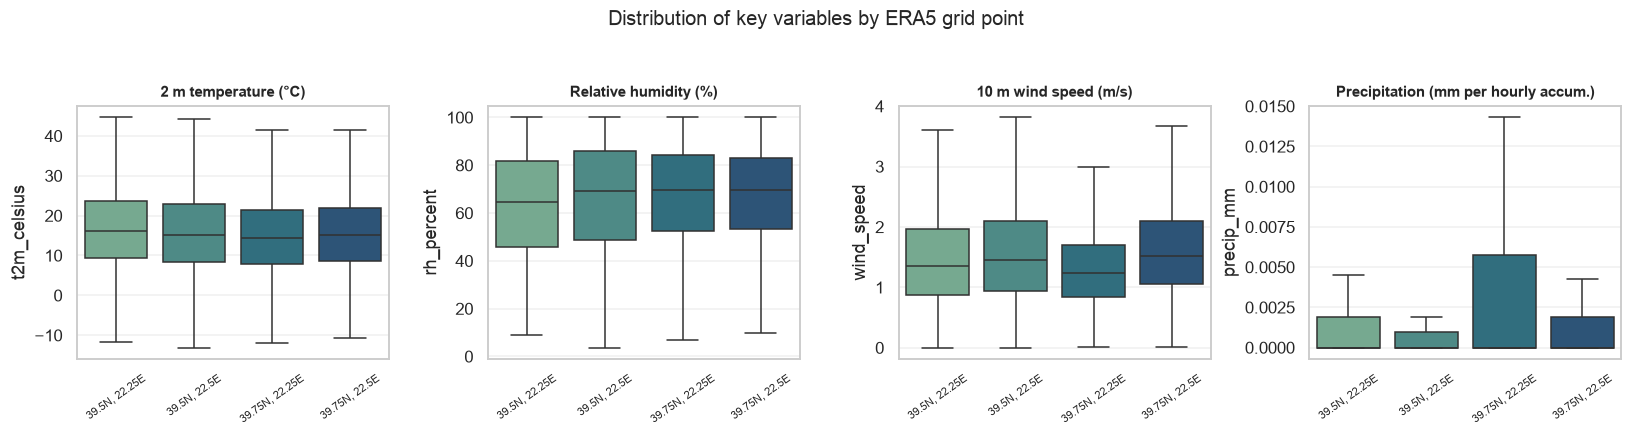

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))
for ax, v in zip(axes, ["t2m_celsius", "rh_percent", "wind_speed", "precip_mm"]):
    sns.boxplot(data=df, x="point", y=v, ax=ax, showfliers=False,
                palette="crest", hue="point", legend=False)
    ax.set_title(LABELS[v], fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=35, labelsize=7)
fig.suptitle("Distribution of key variables by ERA5 grid point", y=1.04, fontsize=13)
plt.show()

findfont: Failed to find font weight semibold, now using 700.


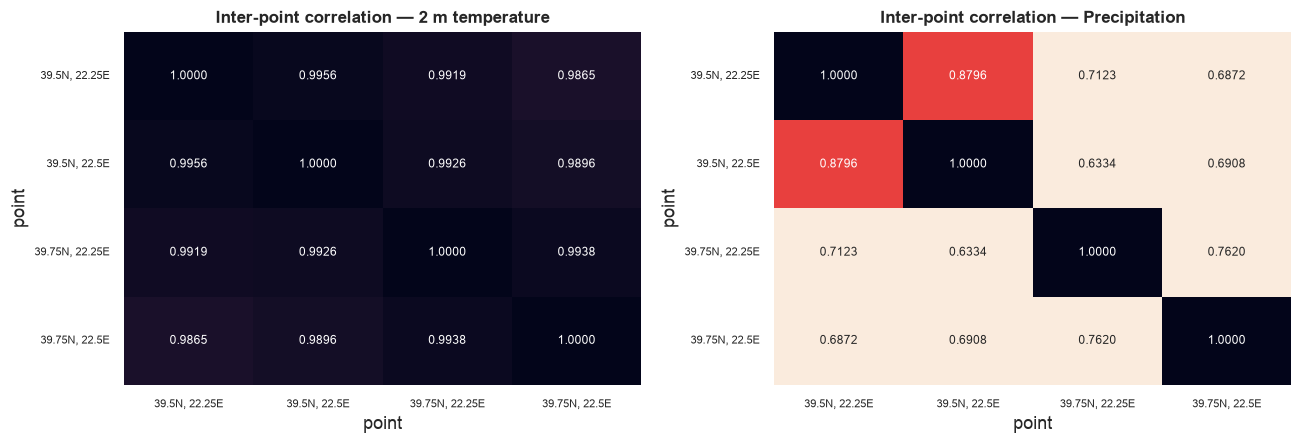

Mean inter-point correlation — temperature:   0.9917
Mean inter-point correlation — precipitation: 0.7276


In [18]:
piv_t = df.pivot_table(index="valid_time", columns="point", values="t2m_celsius")
piv_p = df.pivot_table(index="valid_time", columns="point", values="precip_mm")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, piv, name in zip(axes, [piv_t, piv_p], ["2 m temperature", "Precipitation"]):
    sns.heatmap(piv.corr(), annot=True, fmt=".4f", cmap="rocket_r", vmin=0.8, vmax=1.0,
                cbar=False, ax=ax, annot_kws={"size": 8})
    ax.set_title(f"Inter-point correlation — {name}", fontsize=11)
    ax.tick_params(labelsize=7)
plt.show()

r_t = piv_t.corr().values[np.triu_indices(4, 1)].mean()
r_p = piv_p.corr().values[np.triu_indices(4, 1)].mean()
print(f"Mean inter-point correlation — temperature:   {r_t:.4f}")
print(f"Mean inter-point correlation — precipitation: {r_p:.4f}")

## 5. Averaging the four grid points

This is the step the reference doc flags as the prerequisite for everything downstream: **collapse the four grid
points into one Larissa-representative value per timestamp.** Temperature is effectively identical across the
points, so the average loses almost nothing; precipitation is convective and less coherent, so averaging usefully
suppresses grid-scale noise.

Two details worth getting right:

- **Wind direction cannot be averaged as an angle** (the mean of 350° and 10° is not 180°). We average the `u10`
  and `v10` *components* and recompute direction from the mean vector.
- **Relative humidity and heat index are recomputed** from the averaged temperature and dewpoint rather than
  averaged directly, since both are non-linear functions of their inputs.

After the groupby we set `valid_time` as a **DatetimeIndex**, which is what `.resample()` in section 6 requires.

In [19]:
BASE = ["t2m", "d2m", "u10", "v10", "tp",
        "t2m_celsius", "d2m_celsius", "precip_mm", "precip_mm_scaled",
        "wind_speed", "dewpoint_depression_c"]

# --- the groupby: 4 grid points -> 1 value per timestamp ---
lar = df.groupby("valid_time")[BASE].mean()

# Recompute the non-linear / directional quantities from the averaged inputs
lar["wind_dir"]     = wind_direction(lar["u10"], lar["v10"])
lar["rh_percent"]   = relative_humidity(lar["t2m_celsius"], lar["d2m_celsius"])
lar["heat_index_c"] = compute_heat_index(lar["t2m_celsius"], lar["rh_percent"])

# valid_time is already the index from the groupby; make the DatetimeIndex explicit for .resample()
lar.index = pd.DatetimeIndex(lar.index, name="valid_time")
lar = lar.sort_index()

# Calendar helpers
lar["year"]   = lar.index.year
lar["month"]  = lar.index.month
lar["hour"]   = lar.index.hour
lar["season"] = lar["month"].map(SEASON_OF)

print(f"Rows before averaging: {len(df):,}   after averaging: {len(lar):,}"
      f"   (ratio {len(df)/len(lar):.0f} = the 4 grid points)")
print(f"Index type: {type(lar.index).__name__}   "
      f"range: {lar.index.min():%Y-%m-%d %H:%M} → {lar.index.max():%Y-%m-%d %H:%M}")
lar.head()

Rows before averaging: 210,384   after averaging: 52,596   (ratio 4 = the 4 grid points)
Index type: DatetimeIndex   range: 1990-01-01 00:00 → 2025-12-31 18:00


,t2m,d2m,u10,v10,tp,t2m_celsius,d2m_celsius,precip_mm,precip_mm_scaled,wind_speed,dewpoint_depression_c,wind_dir,rh_percent,heat_index_c,year,month,hour,season
valid_time,,,,,,,,,,,,,,,,,,
1990-01-01 00:00:00,277.912,276.253,-0.554,-1.182,0.000,4.762,3.103,0.047,0.281,1.593,1.659,25.100,89.004,3.618,1990,1,0,DJF
1990-01-01 06:00:00,277.573,276.081,-0.881,-1.299,0.000,4.423,2.931,0.076,0.456,1.713,1.492,34.143,90.030,3.272,1990,1,6,DJF
1990-01-01 12:00:00,280.434,275.951,-3.360,-0.546,0.000,7.284,2.801,0.078,0.466,3.435,4.482,80.775,73.197,5.979,1990,1,12,DJF
1990-01-01 18:00:00,278.467,275.793,-0.957,-0.654,0.000,5.317,2.643,0.006,0.038,1.242,2.674,55.639,82.886,4.068,1990,1,18,DJF
1990-01-02 00:00:00,275.796,274.379,0.082,-0.910,0.000,2.646,1.229,0.005,0.029,1.067,1.418,354.826,90.374,1.326,1990,1,0,DJF


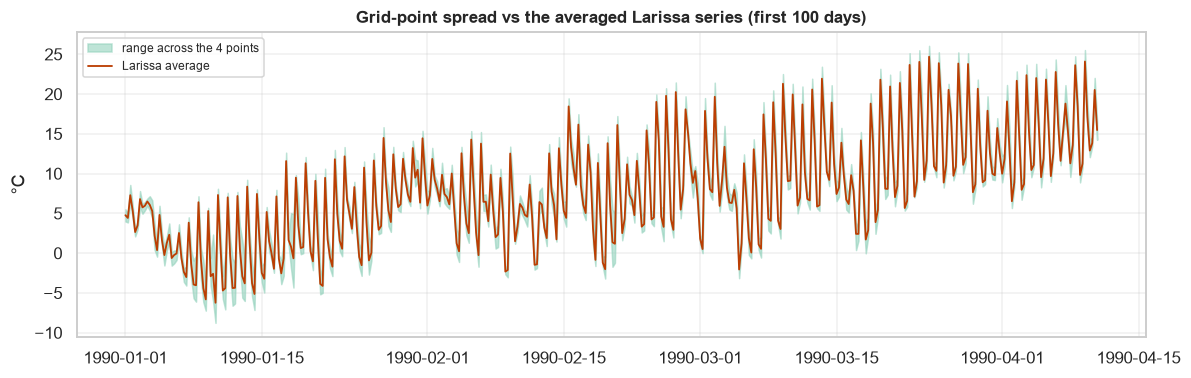

Mean across-point spread at a given timestamp: 2.41 °C


In [20]:
# Confirm the average sits between the point extremes and preserves the signal
comp = pd.DataFrame({
    "min across points":  df.groupby("valid_time")["t2m_celsius"].min(),
    "Larissa average":    lar["t2m_celsius"],
    "max across points":  df.groupby("valid_time")["t2m_celsius"].max(),
}).head(400)

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.fill_between(comp.index, comp["min across points"], comp["max across points"],
                color="#94d2bd", alpha=0.6, label="range across the 4 points")
ax.plot(comp.index, comp["Larissa average"], color="#bb3e03", lw=1.2, label="Larissa average")
ax.set_title("Grid-point spread vs the averaged Larissa series (first 100 days)", fontsize=11)
ax.set_ylabel("°C"); ax.legend(fontsize=8)
plt.show()

print("Mean across-point spread at a given timestamp: "
      f"{(df.groupby('valid_time')['t2m_celsius'].max() - df.groupby('valid_time')['t2m_celsius'].min()).mean():.2f} °C")

## 6. Resampling to daily

The averaged series still holds four readings per day (00, 06, 12, 18 UTC). *Resampling to daily* collapses those
four into one value per day, because the calculations that follow — heatwave detection, tropical nights, SPI,
monthly aggregation — operate on daily or monthly data, not 6-hourly data.

The tricky part is that **different variables must be collapsed differently**:

| Variable | How to collapse | Why |
|---|---|---|
| `t2m_celsius` | `max` **and** `min` | Heatwave detection needs the daily maximum; tropical nights need the daily minimum (must stay above 20 °C overnight) |
| `precip_mm` | `sum` | Precipitation is cumulative, not a snapshot — summing gives the daily total |
| Wind / dewpoint / RH | `mean` | No strong reason to care about daily max/min the way there is with temperature |

**What `.resample()` does:** `.resample('D')` groups timestamp-indexed data by calendar day; the aggregator that
follows — `.max()`, `.min()`, `.sum()`, `.mean()` — tells it how to combine the four readings within that day into
one number. It only works on a DatetimeIndex, which is why section 5 set one.

In [21]:
daily = pd.DataFrame({
    # temperature: max AND min, per the table above
    "tmax_c":           lar["t2m_celsius"].resample("D").max(),
    "tmin_c":           lar["t2m_celsius"].resample("D").min(),
    "tmean_c":          lar["t2m_celsius"].resample("D").mean(),
    # precipitation: cumulative, so sum
    "precip_mm":        lar["precip_mm"].resample("D").sum(),
    "precip_mm_scaled": lar["precip_mm_scaled"].resample("D").sum(),
    # everything else: daily mean (plus a max/min where it is genuinely useful)
    "wind_avg":         lar["wind_speed"].resample("D").mean(),
    "wind_max":         lar["wind_speed"].resample("D").max(),
    "d2m_celsius":      lar["d2m_celsius"].resample("D").mean(),
    "rh_mean_percent":  lar["rh_percent"].resample("D").mean(),
    "rh_min_percent":   lar["rh_percent"].resample("D").min(),
    "heat_index_max_c": lar["heat_index_c"].resample("D").max(),
})

daily["dtr_c"]  = daily["tmax_c"] - daily["tmin_c"]     # diurnal temperature range
daily["year"]   = daily.index.year
daily["month"]  = daily.index.month
daily["season"] = daily["month"].map(SEASON_OF)

print(f"{len(lar):,} six-hourly rows → {len(daily):,} daily rows "
      f"({len(daily)/365.25:.1f} years, no gaps: {daily.isna().sum().sum() == 0})")
daily.head()

52,596 six-hourly rows → 13,149 daily rows (36.0 years, no gaps: True)


,tmax_c,tmin_c,tmean_c,precip_mm,precip_mm_scaled,wind_avg,wind_max,d2m_celsius,rh_mean_percent,rh_min_percent,heat_index_max_c,dtr_c,year,month,season
valid_time,,,,,,,,,,,,,,,
1990-01-01,7.284,4.423,5.447,0.207,1.241,1.996,3.435,2.870,83.779,73.197,5.979,2.861,1990,1,DJF
1990-01-02,6.794,2.646,4.667,0.087,0.524,0.974,1.589,1.786,82.079,70.299,5.364,4.147,1990,1,DJF
1990-01-03,6.484,5.301,5.952,0.151,0.903,1.103,1.171,2.422,78.232,70.677,5.327,1.182,1990,1,DJF
1990-01-04,4.797,0.371,2.244,0.036,0.214,1.566,2.190,-3.489,66.802,48.752,2.605,4.426,1990,1,DJF
1990-01-05,2.309,-0.618,0.681,0.415,2.491,2.223,3.974,-4.905,66.850,53.401,-0.010,2.927,1990,1,DJF


### 6.1 Resampling a second time — daily to monthly

SPI works on monthly totals, so precipitation gets resampled again. `'MS'` is month-start frequency, which labels
each month by its first day.

In [22]:
monthly = pd.DataFrame({
    "precip_mm":        lar["precip_mm"].resample("MS").sum(),
    "precip_mm_scaled": lar["precip_mm_scaled"].resample("MS").sum(),
    "tmean_c":          lar["t2m_celsius"].resample("MS").mean(),
    "tmax_mean_c":      daily["tmax_c"].resample("MS").mean(),
    "tmin_mean_c":      daily["tmin_c"].resample("MS").mean(),
    "rh_mean_percent":  lar["rh_percent"].resample("MS").mean(),
    "wind_avg":         lar["wind_speed"].resample("MS").mean(),
    "wet_days":         (daily["precip_mm_scaled"] >= 1.0).resample("MS").sum(),
})
monthly["year"] = monthly.index.year
monthly["month"] = monthly.index.month

print(f"{len(monthly)} monthly rows — this is the SPI-ready frame.")
print("SPI itself is not computed here: it needs a gamma fit per calendar month, which belongs")
print("in the drought-analysis notebook. `monthly['precip_mm_scaled']` is the input it expects.")
monthly.head()

432 monthly rows — this is the SPI-ready frame.
SPI itself is not computed here: it needs a gamma fit per calendar month, which belongs
in the drought-analysis notebook. `monthly['precip_mm_scaled']` is the input it expects.


,precip_mm,precip_mm_scaled,tmean_c,tmax_mean_c,tmin_mean_c,rh_mean_percent,wind_avg,wet_days,year,month
valid_time,,,,,,,,,,
1990-01-01,1.049,6.294,3.048,8.620,-0.442,73.510,1.249,2,1990,1
1990-02-01,4.328,25.966,7.237,13.110,2.935,69.642,1.635,6,1990,2
1990-03-01,3.831,22.986,11.174,18.721,6.037,54.504,1.713,3,1990,3
1990-04-01,4.492,26.952,14.894,20.775,10.619,57.730,1.893,7,1990,4
1990-05-01,3.902,23.412,19.082,24.768,14.206,52.976,1.548,6,1990,5


## 7. Univariate distributions

In [23]:
summary = lar[ANALYSIS].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T
summary["skew"] = lar[ANALYSIS].skew()
summary["kurtosis"] = lar[ANALYSIS].kurtosis()
summary.round(3)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew,kurtosis
t2m_celsius,"52,596.000",15.602,9.115,-16.221,-2.550,1.391,8.529,15.217,22.457,30.941,35.331,43.258,0.120,-0.678
d2m_celsius,"52,596.000",8.216,5.986,-18.822,-7.637,-2.743,4.329,8.767,12.954,16.634,18.369,21.477,-0.549,-0.059
rh_percent,"52,596.000",65.690,19.866,5.062,22.942,30.648,50.423,68.002,82.818,93.026,96.316,100.000,-0.362,-0.905
heat_index_c,"52,596.000",14.868,9.537,-19.659,-4.750,-0.285,7.531,14.641,22.228,30.275,34.709,42.020,0.032,-0.719
dewpoint_depression_c,"52,596.000",7.386,5.729,0.000,0.549,1.058,2.770,5.817,10.667,18.987,23.797,42.285,1.062,0.650
wind_speed,"52,596.000",1.575,0.886,0.110,0.422,0.610,1.010,1.370,1.867,3.375,4.892,9.811,1.996,5.946
precip_mm,"52,596.000",0.071,0.296,0.000,0.000,0.000,0.000,0.000,0.006,0.388,1.383,12.365,9.709,164.071


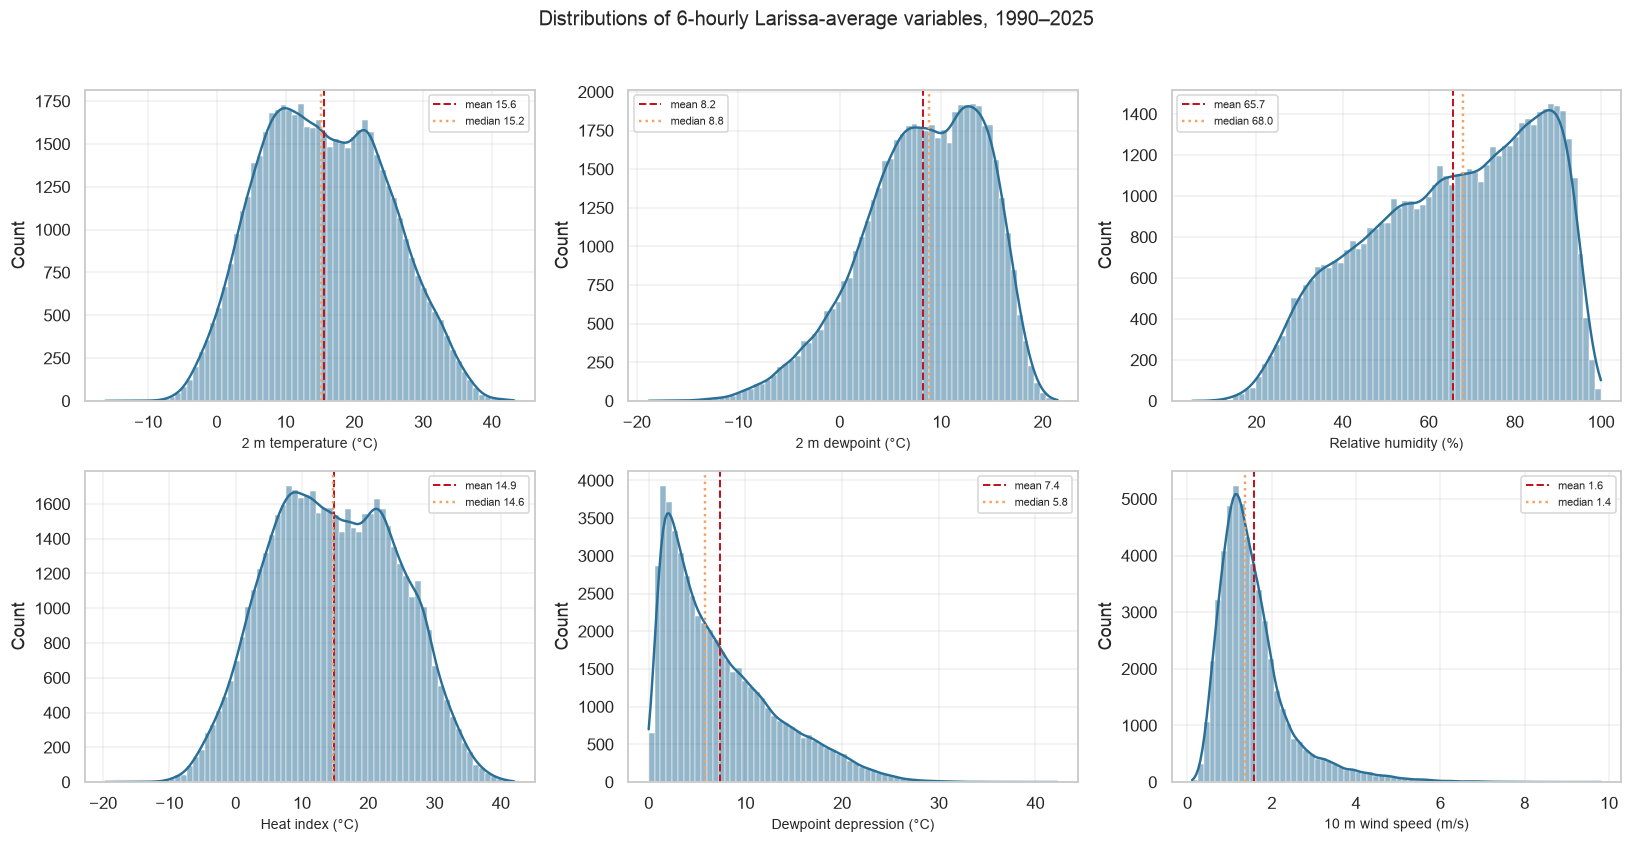

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
for ax, v in zip(axes.ravel(), ["t2m_celsius", "d2m_celsius", "rh_percent",
                                "heat_index_c", "dewpoint_depression_c", "wind_speed"]):
    sns.histplot(lar[v], bins=70, kde=True, ax=ax, color="#2a6f97",
                 edgecolor=None, line_kws={"lw": 1.6})
    ax.axvline(lar[v].mean(), color="#c1121f", ls="--", lw=1.3,
               label=f"mean {lar[v].mean():.1f}")
    ax.axvline(lar[v].median(), color="#f4a261", ls=":", lw=1.6,
               label=f"median {lar[v].median():.1f}")
    ax.set_xlabel(LABELS[v], fontsize=9)
    ax.legend(fontsize=7.5)
fig.suptitle("Distributions of 6-hourly Larissa-average variables, 1990–2025", y=1.02, fontsize=13)
plt.show()

6-hourly records with ≥0.01 mm  :  12,077  (22.96%)
6-hourly records with < 0.01 mm :  40,519  (77.04%)

Distribution of the wet records only (mm, unscaled):


,precip_mm
count,"12,077.000"
mean,0.306
std,0.556
min,0.010
50%,0.100
90%,0.832
99%,2.544
max,12.365


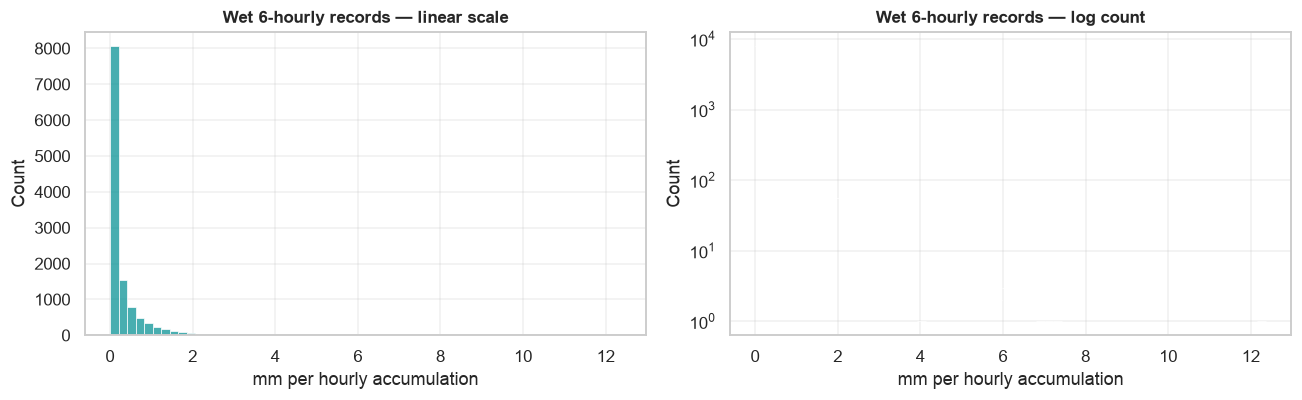

In [25]:
# Precipitation is overwhelmingly dry — describe the mixture rather than plotting a useless histogram
wet = lar["precip_mm"] > 0.01
print(f"6-hourly records with ≥0.01 mm  : {int(wet.sum()):>7,}  ({wet.mean():.2%})")
print(f"6-hourly records with < 0.01 mm : {int((~wet).sum()):>7,}  ({(~wet).mean():.2%})")
print("\nDistribution of the wet records only (mm, unscaled):")
display(lar.loc[wet, "precip_mm"].describe(percentiles=[.5, .9, .99]).round(3).to_frame())

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
sns.histplot(lar.loc[wet, "precip_mm"], bins=60, ax=axes[0], color="#0a9396", edgecolor=None)
axes[0].set_title("Wet 6-hourly records — linear scale", fontsize=11)
axes[0].set_xlabel("mm per hourly accumulation")
sns.histplot(lar.loc[wet, "precip_mm"], bins=60, ax=axes[1], color="#0a9396",
             edgecolor=None, log_scale=(False, True))
axes[1].set_title("Wet 6-hourly records — log count", fontsize=11)
axes[1].set_xlabel("mm per hourly accumulation")
plt.show()

## 8. Seasonality — monthly climatology

Larissa sits inland in the Thessalian plain, sheltered from the sea by the Pindus range to the west and
Mount Olympus / the Pilio hills to the east — a semi-continental variant of a hot-summer Mediterranean climate
(Köppen *Csa*, bordering *BSk*). The monthly climatology is the single most important structure in this
dataset: almost every variable's variance is dominated by the annual cycle, and the annual temperature swing
should be wider than at a coastal city like Seville.

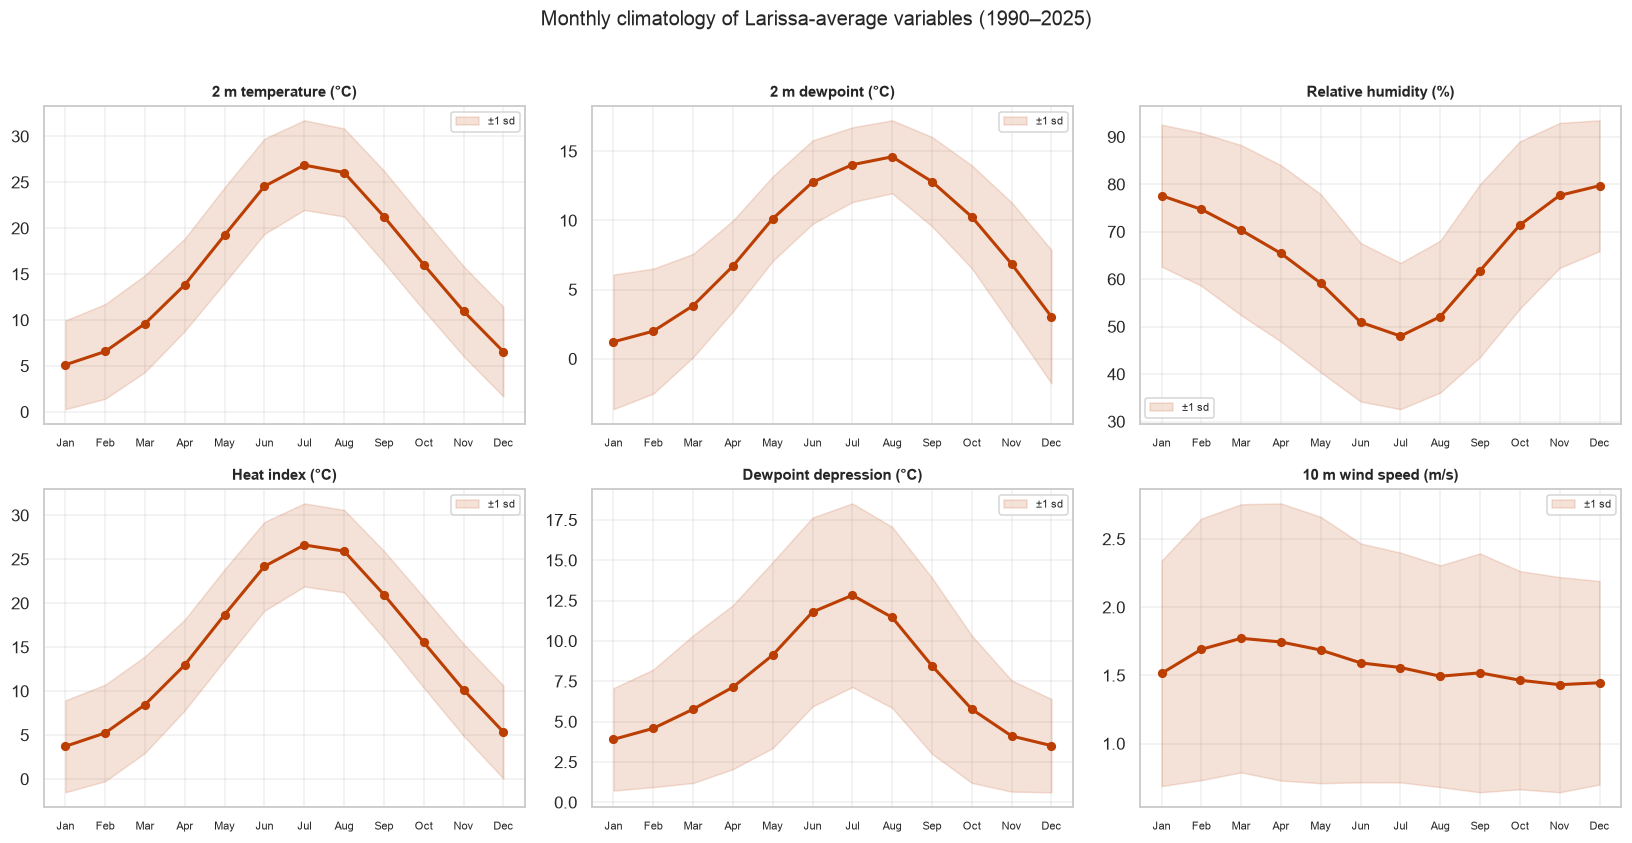

,t2m_celsius,d2m_celsius,rh_percent,heat_index_c,dewpoint_depression_c,wind_speed,precip_mm
month,,,,,,,
1,5.120,1.220,77.610,3.720,3.900,1.510,0.090
2,6.580,2.000,74.720,5.240,4.580,1.690,0.090
3,9.610,3.840,70.330,8.460,5.770,1.770,0.090
4,13.840,6.700,65.430,12.980,7.140,1.750,0.070
5,19.250,10.120,59.140,18.700,9.130,1.690,0.060
6,24.560,12.770,50.930,24.190,11.790,1.590,0.030
7,26.860,14.030,48.010,26.620,12.830,1.560,0.030
8,26.060,14.600,52.110,25.920,11.460,1.490,0.030
9,21.260,12.800,61.800,20.970,8.460,1.520,0.070


In [26]:
mon = lar.groupby("month")[ANALYSIS].mean()
mon_std = lar.groupby("month")[ANALYSIS].std()

fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
for ax, v in zip(axes.ravel(), ["t2m_celsius", "d2m_celsius", "rh_percent",
                                "heat_index_c", "dewpoint_depression_c", "wind_speed"]):
    ax.plot(mon.index, mon[v], "o-", color="#bb3e03", lw=2, ms=5)
    ax.fill_between(mon.index, mon[v] - mon_std[v], mon[v] + mon_std[v],
                    color="#bb3e03", alpha=0.15, label="±1 sd")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MONTHS, fontsize=7.5)
    ax.set_title(LABELS[v], fontsize=10)
    ax.legend(fontsize=7.5)
fig.suptitle("Monthly climatology of Larissa-average variables (1990–2025)", y=1.02, fontsize=13)
plt.show()

mon.round(2)

findfont: Failed to find font weight semibold, now using 700.


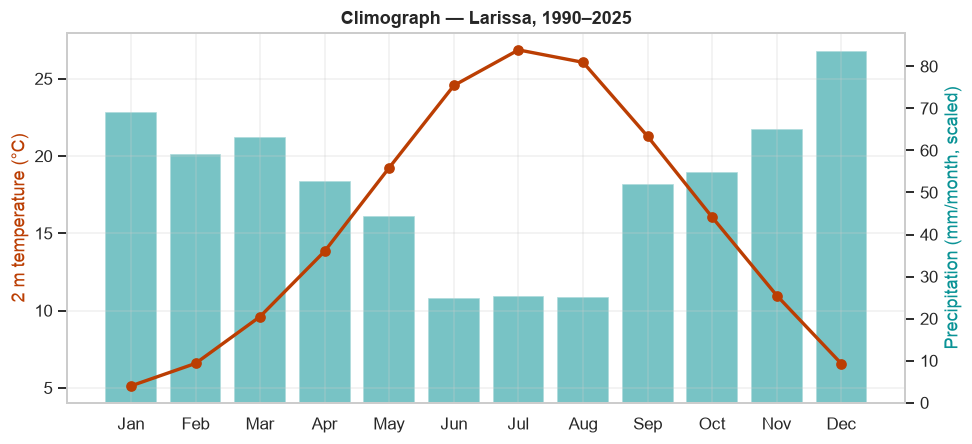

In [27]:
# Climograph, built from the monthly frame created in section 6.1
mon_precip = monthly.groupby("month")["precip_mm_scaled"].mean()

fig, ax1 = plt.subplots(figsize=(9, 4.2))
ax2 = ax1.twinx()
ax2.bar(mon_precip.index, mon_precip.values, color="#0a9396", alpha=0.55, label="precip (scaled)")
ax1.plot(mon.index, mon["t2m_celsius"], "o-", color="#bb3e03", lw=2.2, ms=6, label="temperature")
ax1.set_ylabel("2 m temperature (°C)", color="#bb3e03")
ax2.set_ylabel("Precipitation (mm/month, scaled)", color="#0a9396")
ax1.set_xticks(range(1, 13)); ax1.set_xticklabels(MONTHS)
ax1.set_zorder(2); ax1.patch.set_visible(False)
ax2.grid(False)
ax1.set_title("Climograph — Larissa, 1990–2025")
plt.show()

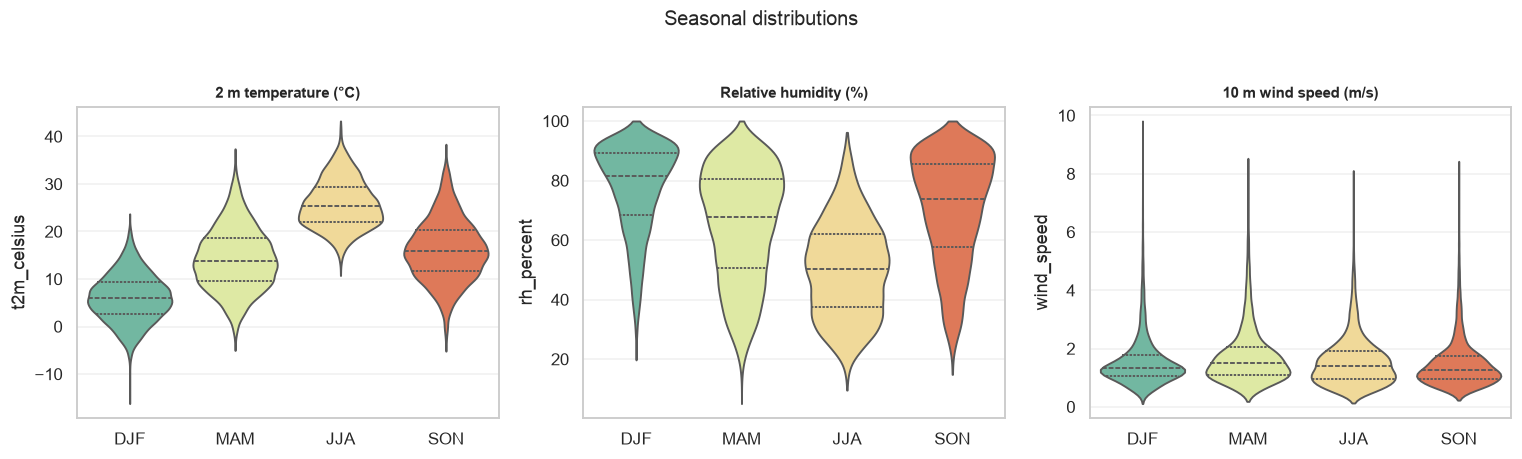

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, v in zip(axes, ["t2m_celsius", "rh_percent", "wind_speed"]):
    sns.violinplot(data=lar, x="season", y=v, order=SEASONS, ax=ax,
                   hue="season", hue_order=SEASONS, palette="Spectral_r",
                   legend=False, cut=0, inner="quartile")
    ax.set_title(LABELS[v], fontsize=10)
    ax.set_xlabel("")
fig.suptitle("Seasonal distributions", y=1.04, fontsize=13)
plt.show()

## 9. Diurnal cycle

Four samples per day only sketch the diurnal cycle — but the sketch shows *when* the sampling misses the true
daily extremes. ERA5 timestamps are UTC; local Greek time is UTC+2 (winter, EET) / UTC+3 (summer, EEST), so
12 UTC is mid-to-late afternoon locally and 06 UTC is shortly after dawn — later relative to local time than
in Seville, since Greece sits further east.

findfont: Failed to find font weight semibold, now using 700.


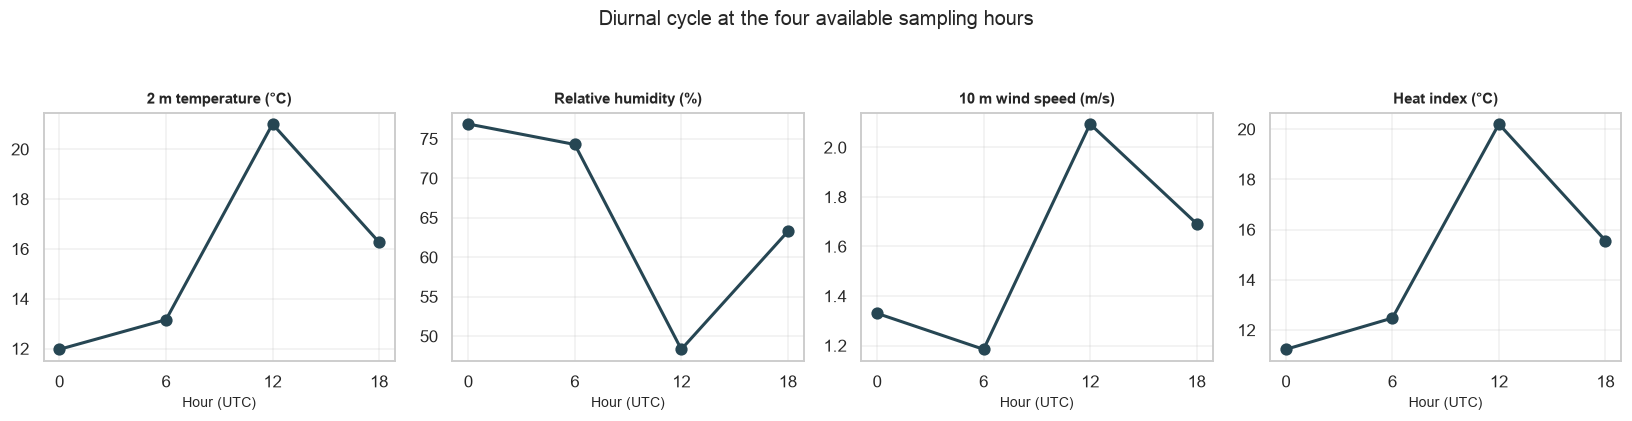

,t2m_celsius,rh_percent,wind_speed,heat_index_c
hour,,,,
0,11.970,76.880,1.330,11.230
6,13.160,74.290,1.180,12.480
12,21.010,48.330,2.090,20.200
18,16.270,63.260,1.690,15.560


In [29]:
diu = lar.groupby("hour")[["t2m_celsius", "rh_percent", "wind_speed", "heat_index_c"]].mean()

fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
for ax, v in zip(axes, ["t2m_celsius", "rh_percent", "wind_speed", "heat_index_c"]):
    ax.plot(diu.index, diu[v], "o-", color="#264653", lw=2, ms=7)
    ax.set_xticks([0, 6, 12, 18])
    ax.set_xlabel("Hour (UTC)", fontsize=9)
    ax.set_title(LABELS[v], fontsize=9.5)
fig.suptitle("Diurnal cycle at the four available sampling hours", y=1.06, fontsize=13)
plt.show()

diu.round(2)

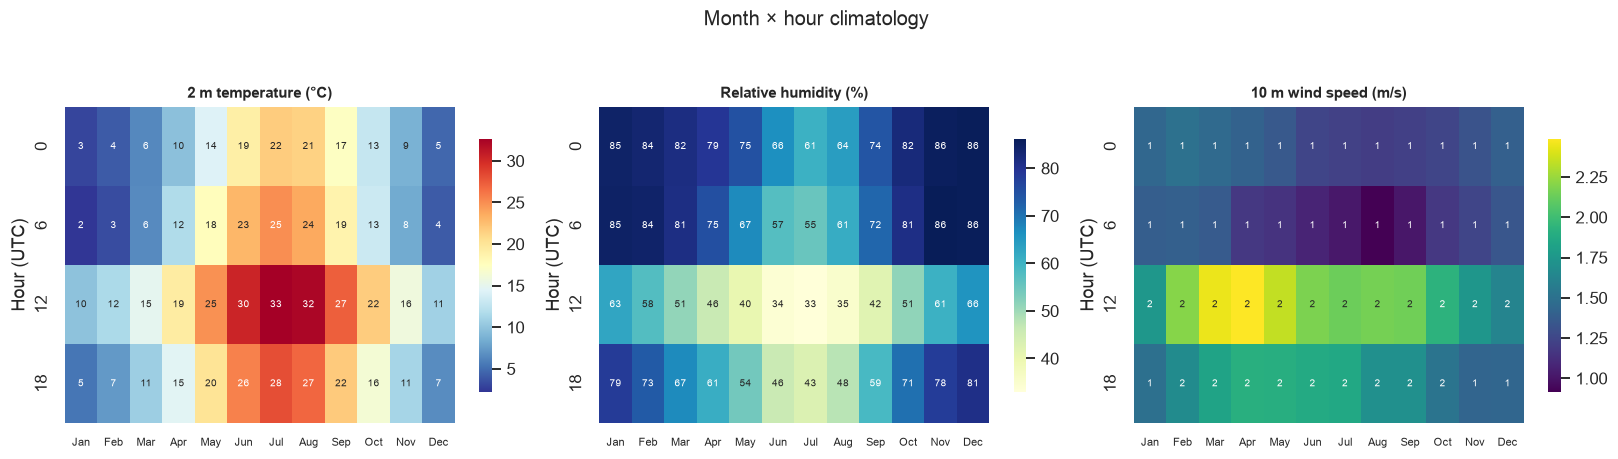

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (v, cm) in zip(axes, [("t2m_celsius", "RdYlBu_r"), ("rh_percent", "YlGnBu"),
                              ("wind_speed", "viridis")]):
    piv = lar.pivot_table(index="hour", columns="month", values=v, aggfunc="mean")
    sns.heatmap(piv, cmap=cm, ax=ax, cbar_kws={"shrink": 0.8},
                annot=True, fmt=".0f", annot_kws={"size": 6.5})
    ax.set_xticklabels(MONTHS, rotation=0, fontsize=7)
    ax.set_title(LABELS[v], fontsize=10)
    ax.set_xlabel(""); ax.set_ylabel("Hour (UTC)")
fig.suptitle("Month × hour climatology", y=1.04, fontsize=13)
plt.show()

### 9.1 How much of the true daily range does 6-hourly sampling capture?

`tmax_c` and `tmin_c` come from four samples, not the full 24 hours, so both are pulled toward the daily mean.
An inland plain like Larissa's typically has a *wider* true diurnal range than a coastal city — clear continental
skies let it radiate heat efficiently overnight — so the inward bias from 6-hourly sampling likely understates
more of the true range here than it did for Seville.

In [31]:
print("Apparent diurnal temperature range from 4 samples/day (°C):")
display(daily["dtr_c"].describe().round(2).to_frame())
print(f"\nMean apparent DTR: {daily['dtr_c'].mean():.2f} °C")
print("Treat tmax_c / tmin_c as *sampled* extremes, consistently biased inward toward the daily")
print("mean — fine for trends and relative comparisons, not for absolute temperature records.")

print("\nWhich sampling hour supplies the daily maximum / minimum (%):")
idx_max = lar.groupby(lar.index.normalize())["t2m_celsius"].idxmax()
idx_min = lar.groupby(lar.index.normalize())["t2m_celsius"].idxmin()
hr_max = lar.loc[idx_max, "hour"].value_counts(normalize=True)
hr_min = lar.loc[idx_min, "hour"].value_counts(normalize=True)
display((pd.DataFrame({"supplies daily max %": hr_max, "supplies daily min %": hr_min})
           .fillna(0).sort_index() * 100).round(1))

Apparent diurnal temperature range from 4 samples/day (°C):


,dtr_c
count,"13,149.000"
mean,9.520
std,3.890
min,0.130
25%,6.800
50%,10.040
75%,12.490
max,19.560



Mean apparent DTR: 9.52 °C
Treat tmax_c / tmin_c as *sampled* extremes, consistently biased inward toward the daily
mean — fine for trends and relative comparisons, not for absolute temperature records.

Which sampling hour supplies the daily maximum / minimum (%):


,supplies daily max %,supplies daily min %
hour,,
0,1.800,64.500
6,0.600,29.000
12,97.000,0.200
18,0.600,6.300


## 10. Long-term trends, 1990–2025

Thirty-six years is short for climate-trend detection, so we report both ordinary least squares and the
outlier-resistant Theil–Sen slope, with the OLS p-value and Kendall's tau. Trends are **per decade**.

**Reading the `significant (p<0.05)` column:** it only checks the OLS p-value against the conventional
95%-confidence threshold, testing the null hypothesis "the true slope is zero." `False` does not mean
"no trend" — with only 36 years of data, it means the observed slope can't be distinguished from noise
at that threshold; a genuine but weak or noisy trend can easily land here. It also does **not** account
for the `tau p-value` column sitting right next to it: Kendall's tau is a rank-based test that is far
less sensitive to a single extreme year dominating the fit, so OLS and Kendall can legitimately disagree
— OLS failing to clear 0.05 while Kendall's tau clears it is a sign of a real trend obscured by one
outlier year, not a sign the trend isn't there. Section 10.4 below is a concrete example of exactly
this split.

In [32]:
annual = pd.DataFrame({
    "t2m_mean":        lar.groupby("year")["t2m_celsius"].mean(),
    "d2m_mean":        lar.groupby("year")["d2m_celsius"].mean(),
    "rh_mean":         lar.groupby("year")["rh_percent"].mean(),
    "heat_index_mean": lar.groupby("year")["heat_index_c"].mean(),
    "dpd_mean":        lar.groupby("year")["dewpoint_depression_c"].mean(),
    "wind_mean":       lar.groupby("year")["wind_speed"].mean(),
    "t2m_p95":         lar.groupby("year")["t2m_celsius"].quantile(0.95),
    "t2m_p05":         lar.groupby("year")["t2m_celsius"].quantile(0.05),
    "tmax_mean":       daily.groupby("year")["tmax_c"].mean(),
    "tmin_mean":       daily.groupby("year")["tmin_c"].mean(),
    "precip_scaled":   daily.groupby("year")["precip_mm_scaled"].sum(),
})


def trend_table(frame, cols, per_decade=True):
    scale = 10.0 if per_decade else 1.0
    x = frame.index.values.astype(float)
    rows = []
    for c in cols:
        y = frame[c].values.astype(float)
        lr = stats.linregress(x, y)
        ts_slope, ts_int, ts_lo, ts_hi = stats.theilslopes(y, x, 0.95)
        tau, tau_p = stats.kendalltau(x, y)
        rows.append({
            "variable": c,
            "OLS slope/decade": lr.slope * scale,
            "OLS p-value": lr.pvalue,
            "Theil-Sen slope/decade": ts_slope * scale,
            "Theil-Sen 95% low": ts_lo * scale,
            "Theil-Sen 95% high": ts_hi * scale,
            "Kendall tau": tau,
            "tau p-value": tau_p,
            "significant (p<0.05)": lr.pvalue < 0.05,
        })
    return pd.DataFrame(rows).set_index("variable")


trends = trend_table(annual, list(annual.columns))
trends.round(4)

,OLS slope/decade,OLS p-value,Theil-Sen slope/decade,Theil-Sen 95% low,Theil-Sen 95% high,Kendall tau,tau p-value,significant (p<0.05)
variable,,,,,,,,
t2m_mean,0.501,0.000,0.492,0.317,0.653,0.613,0.000,True
d2m_mean,0.186,0.060,0.185,-0.035,0.387,0.203,0.081,False
rh_mean,-0.990,0.010,-1.171,-1.879,-0.343,-0.298,0.010,True
heat_index_mean,0.517,0.000,0.510,0.358,0.687,0.584,0.000,True
dpd_mean,0.315,0.003,0.347,0.102,0.592,0.321,0.006,True
wind_mean,0.010,0.289,0.012,-0.007,0.032,0.171,0.141,False
t2m_p95,0.654,0.000,0.639,0.389,0.870,0.536,0.000,True
t2m_p05,0.448,0.012,0.446,0.054,0.804,0.260,0.025,True
tmax_mean,0.631,0.000,0.641,0.415,0.829,0.597,0.000,True


findfont: Failed to find font weight semibold, now using 700.


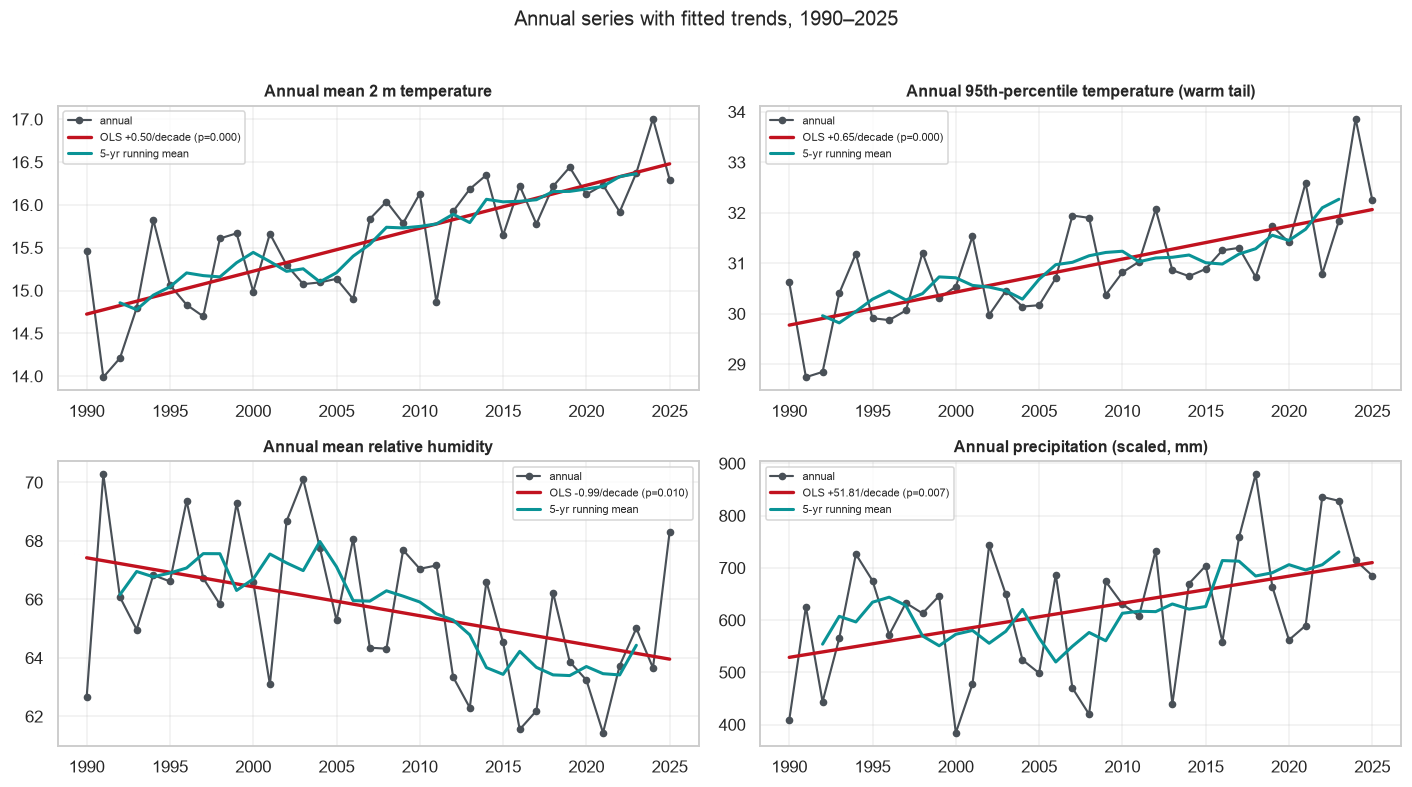

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for ax, (v, ttl) in zip(axes.ravel(), [
        ("t2m_mean", "Annual mean 2 m temperature"),
        ("t2m_p95", "Annual 95th-percentile temperature (warm tail)"),
        ("rh_mean", "Annual mean relative humidity"),
        ("precip_scaled", "Annual precipitation (scaled, mm)")]):
    y = annual[v]
    ax.plot(y.index, y.values, "o-", color="#495057", lw=1.4, ms=4, label="annual")
    lr = stats.linregress(y.index.astype(float), y.values)
    ax.plot(y.index, lr.intercept + lr.slope * y.index, "-", color="#c1121f", lw=2.2,
            label=f"OLS {lr.slope*10:+.2f}/decade (p={lr.pvalue:.3f})")
    ax.plot(y.index, y.rolling(5, center=True).mean(), "-", color="#0a9396", lw=2,
            label="5-yr running mean")
    ax.set_title(ttl, fontsize=10.5)
    ax.legend(fontsize=7.5)
fig.suptitle("Annual series with fitted trends, 1990–2025", y=1.02, fontsize=13)
plt.show()

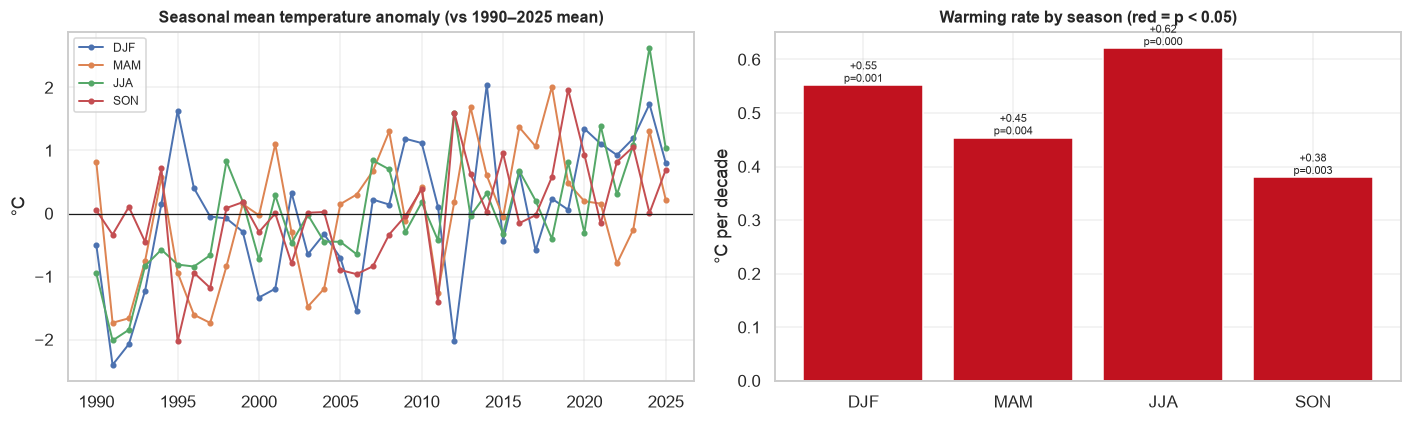

,OLS slope/decade,OLS p-value,Theil-Sen slope/decade,significant (p<0.05)
variable,,,,
DJF,0.552,0.001,0.575,True
MAM,0.454,0.004,0.452,True
JJA,0.621,0.000,0.563,True
SON,0.380,0.003,0.349,True


In [34]:
# Are the trends seasonally uniform?
seas_ann = lar.pivot_table(index="year", columns="season", values="t2m_celsius", aggfunc="mean")
seas_tr = trend_table(seas_ann, SEASONS)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for s in SEASONS:
    axes[0].plot(seas_ann.index, seas_ann[s] - seas_ann[s].mean(), "-o", ms=3, lw=1.3, label=s)
axes[0].axhline(0, color="k", lw=0.8)
axes[0].set_title("Seasonal mean temperature anomaly (vs 1990–2025 mean)", fontsize=10.5)
axes[0].set_ylabel("°C"); axes[0].legend(fontsize=8)

bars = axes[1].bar(seas_tr.index, seas_tr["OLS slope/decade"],
                   color=["#4361ee" if p >= .05 else "#c1121f" for p in seas_tr["OLS p-value"]])
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_title("Warming rate by season (red = p < 0.05)", fontsize=10.5)
axes[1].set_ylabel("°C per decade")
for b, (v, p) in zip(bars, seas_tr[["OLS slope/decade", "OLS p-value"]].values):
    axes[1].text(b.get_x() + b.get_width()/2, v, f"{v:+.2f}\np={p:.3f}",
                 ha="center", va="bottom" if v >= 0 else "top", fontsize=7.5)
plt.show()

seas_tr[["OLS slope/decade", "OLS p-value", "Theil-Sen slope/decade", "significant (p<0.05)"]].round(4)

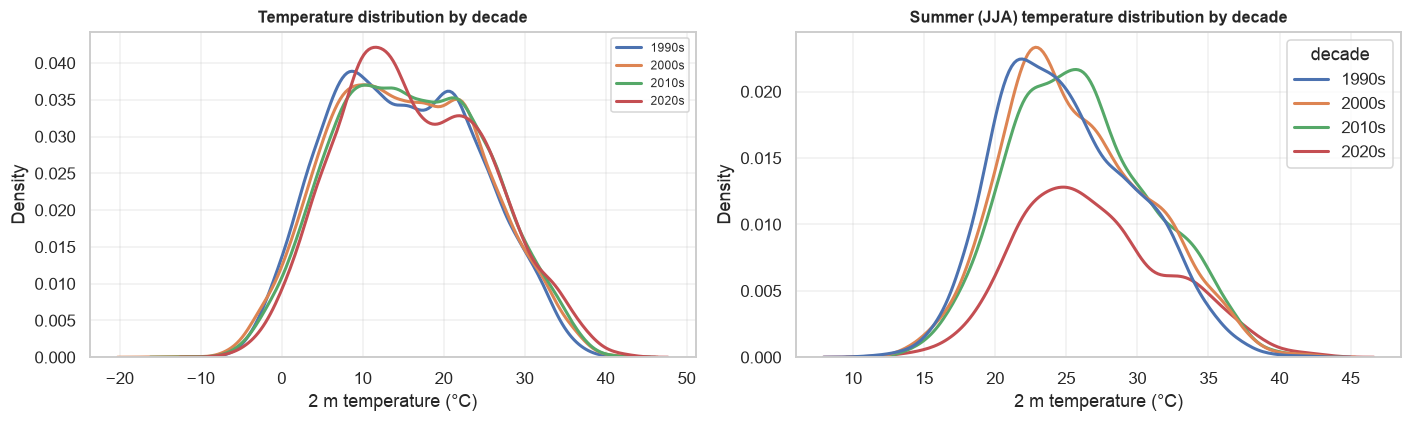

Note: the '2020s' group holds 6 years so far, not a full decade — read it with that in mind.


,mean,std,min,max,p95
decade,,,,,
1990s,15.020,8.980,-8.610,42.170,30.140
2000s,15.380,9.200,-16.220,42.390,30.910
2010s,15.980,9.110,-12.220,41.510,31.130
2020s,16.320,9.120,-8.140,43.260,32.180


In [35]:
# Decadal comparison: has the distribution shifted, or stretched?
lar["decade"] = (lar["year"] // 10 * 10).astype(str) + "s"
dec = lar.groupby("decade")["t2m_celsius"].agg(["mean", "std", "min", "max",
                                               lambda s: s.quantile(.95)])
dec.columns = ["mean", "std", "min", "max", "p95"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for d, g in lar.groupby("decade"):
    sns.kdeplot(g["t2m_celsius"], ax=axes[0], lw=2, label=d)
axes[0].set_title("Temperature distribution by decade", fontsize=10.5)
axes[0].set_xlabel(LABELS["t2m_celsius"]); axes[0].legend(fontsize=8)

sns.kdeplot(data=lar[lar["season"] == "JJA"], x="t2m_celsius", hue="decade", ax=axes[1], lw=2)
axes[1].set_title("Summer (JJA) temperature distribution by decade", fontsize=10.5)
axes[1].set_xlabel(LABELS["t2m_celsius"])
plt.show()

last_decade = dec.index[-1]
n_years_last = lar[lar["decade"] == last_decade]["year"].nunique()
print(f"Note: the '{last_decade}' group holds {n_years_last} years so far, not a full decade "
      f"— read it with that in mind.")
dec.round(2)

### 10.4 SPI-3 and precipitation volatility trends

`Calculating_SPI_for_Larissa.ipynb` computes SPI-3 (3-month Standardised Precipitation Index, a
gamma distribution fit on the fixed 1990–2020 reference period) and the volatility metric this
project uses instead of a single combined drought/flood index: **`min_spi3`** (drought depth — the
driest 3-month window each year) and **`max_week_precip_mm`** (flood intensity — the wettest single
week each year), kept as two parallel series rather than collapsed into one number. Both get the
same OLS / Theil-Sen / Kendall-tau trend treatment as every other indicator above, reusing the same
`trend_table()` function defined in section 10.

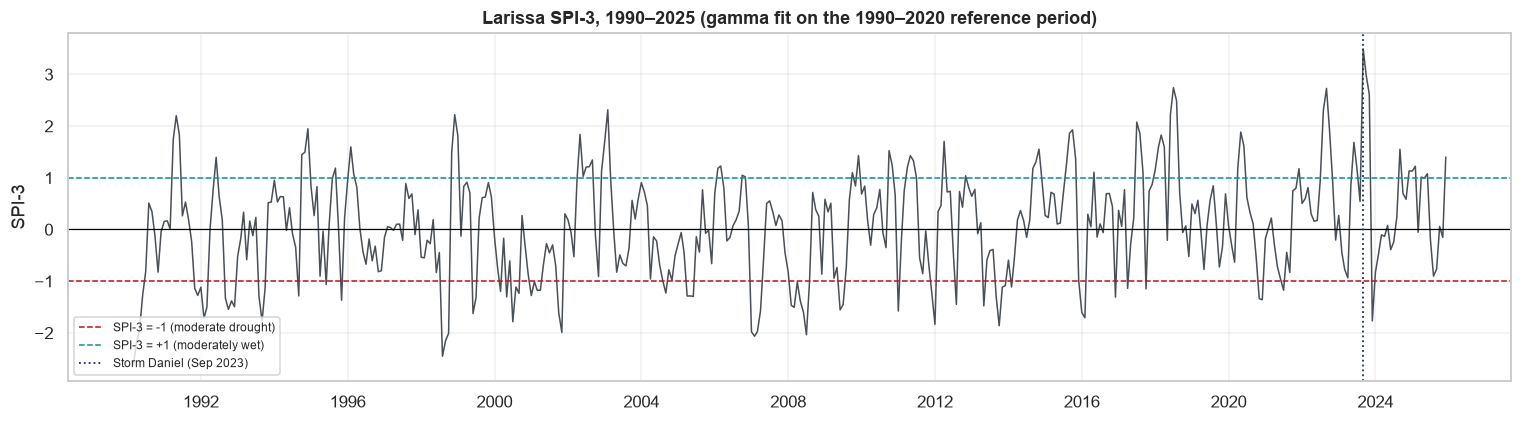

,min_spi3,max_week_precip_mm
year,,
2018,-0.523,95.181
2019,-0.772,96.801
2020,-1.359,91.356
2021,-1.175,65.660
2022,-0.204,90.689
2023,-1.767,253.066
2024,-0.825,99.235
2025,-0.902,138.562


In [36]:
spi_monthly = pd.read_csv(OUT / "larissa_spi3_monthly.csv", parse_dates=["valid_time"])
volatility = pd.read_csv(OUT / "larissa_volatility_annual.csv", index_col=0).rename_axis("year")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(spi_monthly["valid_time"], spi_monthly["spi3"], color="#495057", linewidth=1)
ax.axhline(0, color="black", linewidth=0.8)
ax.axhline(-1, color="#c1121f", linestyle="--", linewidth=1, label="SPI-3 = -1 (moderate drought)")
ax.axhline(1, color="#0a9396", linestyle="--", linewidth=1, label="SPI-3 = +1 (moderately wet)")
ax.axvline(pd.Timestamp("2023-09-01"), color="#1d3557", linestyle=":", linewidth=1.2,
           label="Storm Daniel (Sep 2023)")
ax.set_title("Larissa SPI-3, 1990–2025 (gamma fit on the 1990–2020 reference period)")
ax.set_ylabel("SPI-3")
ax.legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

volatility.tail(8)

In [37]:
volatility_trends = trend_table(volatility, list(volatility.columns))
volatility_trends.round(4)

,OLS slope/decade,OLS p-value,Theil-Sen slope/decade,Theil-Sen 95% low,Theil-Sen 95% high,Kendall tau,tau p-value,significant (p<0.05)
variable,,,,,,,,
min_spi3,0.183,0.061,0.189,-0.016,0.401,0.209,0.072,False
max_week_precip_mm,12.574,0.055,7.700,1.093,19.169,0.270,0.021,False


**Worked example of the OLS-vs-Kendall split described in section 10's intro:** both indicators
above show `significant (p<0.05) = False`, since OLS p = 0.061 (`min_spi3`) and p = 0.055
(`max_week_precip_mm`) — both miss the 0.05 cutoff, but only just. Read `tau p-value` alongside it,
not the boolean column alone: for `max_week_precip_mm`, Kendall's tau p-value is **0.021** —
significant — while OLS just misses it. That split is exactly what a single dominant outlier year
(2023, i.e. Storm Daniel) does to a 36-point OLS fit: it inflates the OLS p-value while the
rank-based Kendall test, which cares about relative ordering rather than magnitude, still detects the
trend. Read as: a real, if not airtight-by-every-test, intensifying trend in flood intensity.

This is corroborated directly in `baseline_models.ipynb`, which now fits `min_spi3` and
`max_week_precip_mm` as their own baseline-model target columns: `max_week_precip_mm` is won by
`ols_last_15yr` (MAE 42.2 → 31.5 vs. the naive baseline, the only positive R² among Larissa's four
precipitation-family indicators there), matching the Kendall-tau signal above. `min_spi3`, however,
is won there by `ols_full_history` (MAE 0.563 → 0.452), *not* `ols_last_15yr` — an exception to the
"avoid full-history OLS" guidance drawn from the original four indicators, plausibly because SPI-3's
own gamma fit already uses 1990–2020 as its reference period, so a full-history OLS trend on
`min_spi3` is fit almost entirely within that same window rather than diluted by stale old data the
way it was for raw physical quantities. Don't assume the two volatility indicators behave alike just
because they're reported together — the flood side has a real recent trend, but the drought side's
best-supported baseline is the long-run fit.

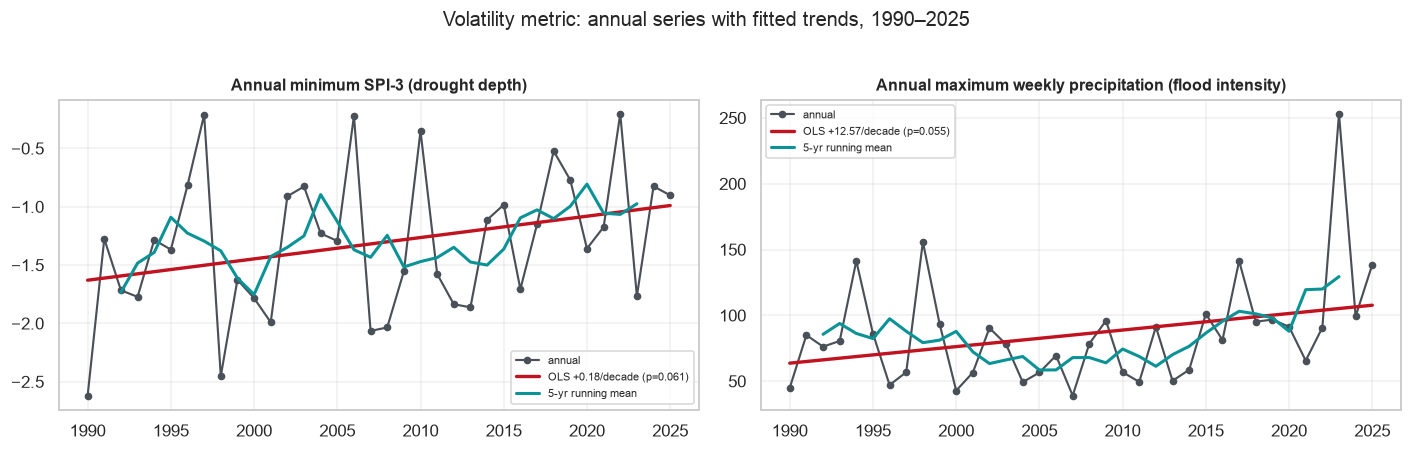

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (v, ttl) in zip(axes, [
        ("min_spi3", "Annual minimum SPI-3 (drought depth)"),
        ("max_week_precip_mm", "Annual maximum weekly precipitation (flood intensity)")]):
    y = volatility[v]
    ax.plot(y.index, y.values, "o-", color="#495057", lw=1.4, ms=4, label="annual")
    lr = stats.linregress(y.index.astype(float), y.values)
    ax.plot(y.index, lr.intercept + lr.slope * y.index, "-", color="#c1121f", lw=2.2,
            label=f"OLS {lr.slope*10:+.2f}/decade (p={lr.pvalue:.3f})")
    ax.plot(y.index, y.rolling(5, center=True).mean(), "-", color="#0a9396", lw=2,
            label="5-yr running mean")
    ax.set_title(ttl, fontsize=10.5)
    ax.legend(fontsize=7.5)
fig.suptitle("Volatility metric: annual series with fitted trends, 1990–2025", y=1.02, fontsize=13)
plt.show()

### 10.5 Testing the drought→flood pairing claim directly

Section 10.4's Storm Daniel discussion is a single-year anecdote — useful as a sanity check, but
not evidence of a general pattern on its own. If a genuine year-over-year drought→flood pairing
exists in this record, it should show up as a **negative** correlation between the same year's
`min_spi3` (that year's worst drought depth — more negative = more severe) and
`max_week_precip_mm` (that year's flood intensity — higher = more severe): years with a deeper
drought minimum also producing a more intense flood week. Computed directly across all 36 years,
not inferred from one data point.

n = 36 years
Pearson  r   = -0.047, p = 0.7875
Spearman rho = +0.176, p = 0.3044


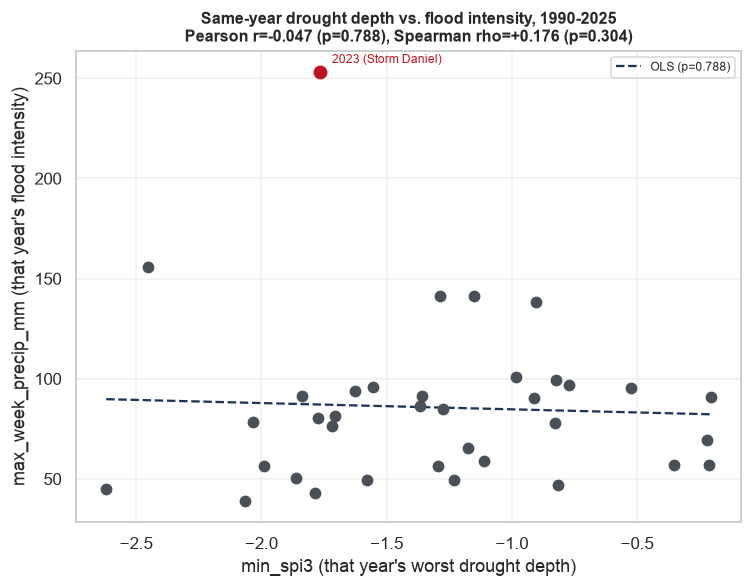

In [39]:
pair = volatility[["min_spi3", "max_week_precip_mm"]].dropna()

pearson_r, pearson_p = stats.pearsonr(pair["min_spi3"], pair["max_week_precip_mm"])
spearman_rho, spearman_p = stats.spearmanr(pair["min_spi3"], pair["max_week_precip_mm"])

print(f"n = {len(pair)} years")
print(f"Pearson  r   = {pearson_r:+.3f}, p = {pearson_p:.4f}")
print(f"Spearman rho = {spearman_rho:+.3f}, p = {spearman_p:.4f}")

fig, ax = plt.subplots(figsize=(7, 5.5))
for yr, row in pair.iterrows():
    is_2023 = yr == 2023
    ax.scatter(row["min_spi3"], row["max_week_precip_mm"],
               color="#c1121f" if is_2023 else "#495057", s=65 if is_2023 else 45, zorder=6)
    if is_2023:
        ax.annotate("2023 (Storm Daniel)", (row["min_spi3"], row["max_week_precip_mm"]),
                    textcoords="offset points", xytext=(8, 6), fontsize=8, color="#c1121f")

lr = stats.linregress(pair["min_spi3"], pair["max_week_precip_mm"])
xs = np.linspace(pair["min_spi3"].min(), pair["min_spi3"].max(), 50)
ax.plot(xs, lr.intercept + lr.slope * xs, "--", color="#1d3557", lw=1.5,
        label=f"OLS (p={lr.pvalue:.3f})")

ax.set_xlabel("min_spi3 (that year's worst drought depth)")
ax.set_ylabel("max_week_precip_mm (that year's flood intensity)")
ax.set_title(f"Same-year drought depth vs. flood intensity, 1990-2025\n"
             f"Pearson r={pearson_r:+.3f} (p={pearson_p:.3f}), Spearman rho={spearman_rho:+.3f} (p={spearman_p:.3f})",
             fontsize=10.5)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Finding: no genuine drought→flood pairing — the correlation is statistically indistinguishable
from zero.**

| Test | Statistic | p-value |
|---|---|---|
| Pearson r | −0.047 | 0.788 |
| Spearman ρ | +0.176 | 0.304 |

Both tests fail to reject "no relationship" by a wide margin, and they don't even agree on
direction — Pearson is (barely) negative, the sign a real pairing would predict, while Spearman is
weakly positive, the opposite sign. Neither is remotely close to p<0.05. This confirms, with the
full 36-year record rather than one data point, what section 10.4 already flagged about Storm
Daniel specifically: the months leading into the September 2023 flood were only mildly dry
(min SPI-3 −0.94 in April) and had already turned wet again by summer — that single year was never
a strong example of drought priming a flood, and it turns out the record has no such pattern in
general. Treat Larissa's drought signal (`min_spi3`) and its flood signal (`max_week_precip_mm`)
as independent phenomena, not two faces of one "volatility" story.

### 10.6 Reframing the volatility story: wet-extreme intensification under uniform stress

The calculations behind `min_spi3` and `max_week_precip_mm` (section 10.4, computed in
`Calculating_SPI_for_Larissa.ipynb`) are unchanged — this section only reframes what they've
already shown, now that the drought side of the original "volatility" hypothesis has been fully
tested and doesn't hold up:

- **Drought is not deepening.** `min_spi3` trends *milder*, not worse (+0.183/decade, p=0.061).
  Longest dry spell trends *shorter* (−2.05/decade, p=0.215). Neither is significant, and both point
  the wrong direction for a "worsening drought" story.
- **Drought does not precede flood.** Section 10.5 tested this directly across all 36 years —
  Pearson r=−0.047 (p=0.788), Spearman ρ=+0.176 (p=0.304). No relationship, in either direction.
- **The wet-extreme side, on the other hand, is real.** `max_week_precip_mm` intensifying
  (Kendall τ p=**0.021**, the outlier-robust test; OLS p=0.055 just misses, likely damped by 2023's
  dominant influence the same way section 10.4 already describes). Max 1-day rainfall also
  significant (OLS p=**0.040**). Annual total precipitation itself is up significantly too
  (+51.8 mm/decade, p=0.0071) — this is not one metric moving in isolation.
- **All of this sits on top of a warming signal that is uniform, not selective.** Every season
  clears p<0.05 (DJF p=0.001, MAM p=0.004, JJA p<0.0001, SON p=0.003), both day and night clear it
  (`tmax_mean` p<0.0001, `tmin_mean` p<0.0001), and both distribution tails clear it (`t2m_p95`
  p<0.0001, `t2m_p05` p=0.0124). Nine of the ten headline metrics in section 17 below are
  significant. There is no quiet season, time of day, or tail in this record — the background
  warming is comprehensive.

**Reframed finding: Larissa's climate-risk signature is uniform background warming (every season,
day and night, both tails) combined with an independently intensifying wet-extreme tail — not the
drought-primes-flood "volatility whiplash" pattern originally hypothesized.** The drought side isn't
part of an intensifying-risk story at all; it's flat to improving. The risk that's actually building
is narrower than originally framed — flood intensity specifically — but it's real, statistically
supported by the outlier-robust test, and occurring against a backdrop of warming stress that
touches literally every metric tested rather than one seasonal or diurnal slice of the year.

## 11. Heat extremes

Two definitions are reported. **Fixed thresholds** are intuitive but sit lower here than station-based ones would,
because spatial averaging smooths peaks and the sampled daily max understates the true one. **Percentile-based**
definitions are threshold-independent and standard in the heatwave literature.

`tmin_c ≥ 20 °C` is the **tropical night** criterion — the overnight minimum never dropping below 20 °C, which is
what makes heat dangerous, since the body gets no chance to recover. On an inland plain like Larissa's, clear
continental nights should make tropical nights considerably rarer than at humid coastal Seville, even where
daytime peak heat is comparable or higher.

Trends in annual counts of hot days and tropical nights:


,OLS slope/decade,OLS p-value,Theil-Sen slope/decade,Theil-Sen 95% low,Theil-Sen 95% high,Kendall tau,tau p-value,significant (p<0.05)
variable,,,,,,,,
days tmax≥30°C,8.411,0.000,9.626,5.200,12.857,0.495,0.000,True
days tmax≥33°C,10.019,0.000,10.000,6.429,13.077,0.565,0.000,True
days tmax≥35°C,6.191,0.000,5.833,2.857,8.571,0.463,0.000,True
days tmax≥37°C,3.072,0.001,1.786,0.714,3.636,0.381,0.002,True
days tmax≥40°C,0.710,0.040,0.000,0.000,0.000,0.258,0.051,True
tropical nights tmin≥20°C,8.313,0.000,7.500,4.118,10.870,0.509,0.000,True
days heat index≥35°C,5.367,0.000,4.545,1.923,7.500,0.403,0.001,True


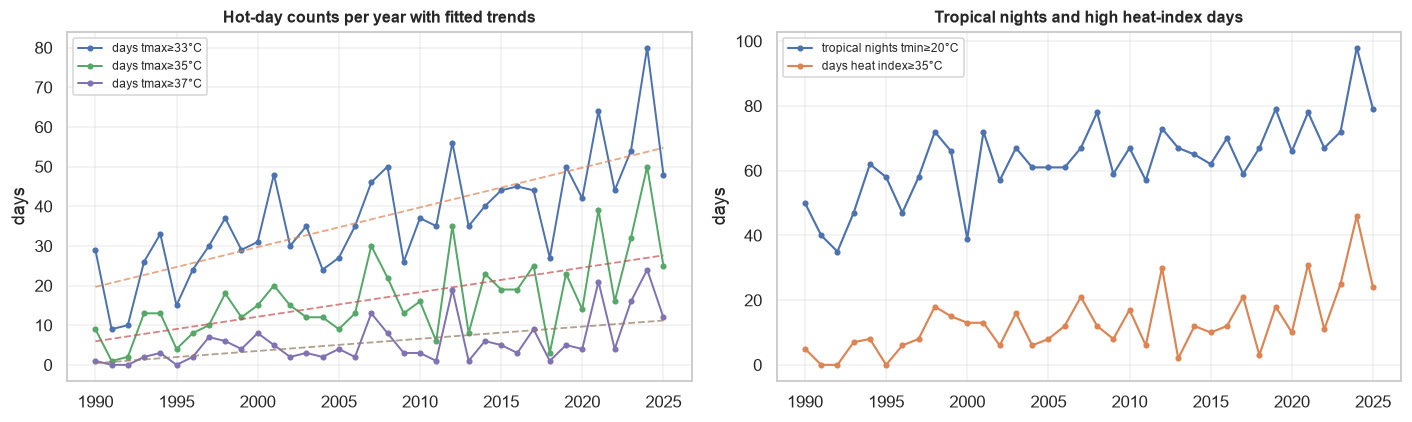

,days tmax≥30°C,days tmax≥33°C,days tmax≥35°C,days tmax≥37°C,days tmax≥40°C,tropical nights tmin≥20°C,days heat index≥35°C
year,,,,,,,
2016,86,45,19,3,1,70,12
2017,87,44,25,9,3,59,21
2018,86,27,3,1,0,67,3
2019,95,50,23,5,1,79,18
2020,93,42,14,4,0,66,10
2021,98,64,39,21,9,78,31
2022,77,44,16,4,0,67,11
2023,76,54,32,16,7,72,25
2024,102,80,50,24,0,98,46


In [40]:
THRESH = [30, 33, 35, 37, 40]
hot = pd.DataFrame({
    f"days tmax≥{t}°C": daily.groupby("year")["tmax_c"].apply(lambda s, t=t: int((s >= t).sum()))
    for t in THRESH
})
hot["tropical nights tmin≥20°C"] = daily.groupby("year")["tmin_c"].apply(lambda s: int((s >= 20).sum()))
hot["days heat index≥35°C"] = daily.groupby("year")["heat_index_max_c"].apply(lambda s: int((s >= 35).sum()))

print("Trends in annual counts of hot days and tropical nights:")
display(trend_table(hot, list(hot.columns)).round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for c in [f"days tmax≥{t}°C" for t in (33, 35, 37)]:
    axes[0].plot(hot.index, hot[c], "-o", ms=3, lw=1.3, label=c)
    lr = stats.linregress(hot.index.astype(float), hot[c].values)
    axes[0].plot(hot.index, lr.intercept + lr.slope*hot.index, "--", lw=1.2, alpha=0.7)
axes[0].set_title("Hot-day counts per year with fitted trends", fontsize=10.5)
axes[0].set_ylabel("days"); axes[0].legend(fontsize=8)

for c in ["tropical nights tmin≥20°C", "days heat index≥35°C"]:
    axes[1].plot(hot.index, hot[c], "-o", ms=3, lw=1.4, label=c)
axes[1].set_title("Tropical nights and high heat-index days", fontsize=10.5)
axes[1].set_ylabel("days"); axes[1].legend(fontsize=8)
plt.show()

hot.tail(10)

In [41]:
# Percentile-based heatwave definition:
#   >=3 consecutive days with tmax_c above the calendar-day 90th percentile,
#   the percentile taken over a +/-7 day window pooled across all years
d = daily.copy()
d["doy"] = d.index.dayofyear

pct = {}
for doy in range(1, 367):
    win = [((doy - 1 + k) % 366) + 1 for k in range(-7, 8)]
    pct[doy] = d.loc[d["doy"].isin(win), "tmax_c"].quantile(0.90)
d["tmax_p90"] = d["doy"].map(pct)
d["exceed"] = d["tmax_c"] > d["tmax_p90"]

grp = (d["exceed"] != d["exceed"].shift()).cumsum()
runs = d[d["exceed"]].groupby(grp[d["exceed"]]).agg(
    start=("tmax_c", lambda s: s.index[0]), length=("tmax_c", "size"),
    peak=("tmax_c", "max"), mean_tmax=("tmax_c", "mean"),
)
hw = runs[runs["length"] >= 3].copy()
hw["year"] = hw["start"].dt.year

hw_year = pd.DataFrame({
    "heatwaves": hw.groupby("year").size(),
    "heatwave days": hw.groupby("year")["length"].sum(),
    "longest (days)": hw.groupby("year")["length"].max(),
}).reindex(range(daily.index.year.min(), daily.index.year.max() + 1)).fillna(0).astype(int)

print(f"Total heatwave events (≥3 consecutive days above calendar-day P90): {len(hw)}")
print("\nTrends in heatwave metrics:")
display(trend_table(hw_year, list(hw_year.columns)).round(4))

print("\n10 longest heatwave events:")
display(hw.nlargest(10, "length")[["start", "length", "peak"]]
          .assign(start=lambda x: x["start"].dt.strftime("%Y-%m-%d")).reset_index(drop=True))

Total heatwave events (≥3 consecutive days above calendar-day P90): 163

Trends in heatwave metrics:


,OLS slope/decade,OLS p-value,Theil-Sen slope/decade,Theil-Sen 95% low,Theil-Sen 95% high,Kendall tau,tau p-value,significant (p<0.05)
variable,,,,,,,,
heatwaves,1.651,0.000,1.667,0.909,2.500,0.491,0.000,True
heatwave days,8.629,0.000,8.619,5.000,11.667,0.514,0.000,True
longest (days),1.412,0.001,1.154,0.500,2.000,0.442,0.000,True



10 longest heatwave events:


,start,length,peak
0,2024-07-08,15,38.997
1,2001-03-18,11,30.966
2,2013-04-25,11,30.852
3,2021-07-27,11,43.018
4,2007-01-18,10,19.136
5,2021-02-01,10,19.641
6,2012-09-25,9,32.742
7,2016-04-12,9,32.676
8,2023-07-18,9,43.258
9,2010-11-27,8,23.716


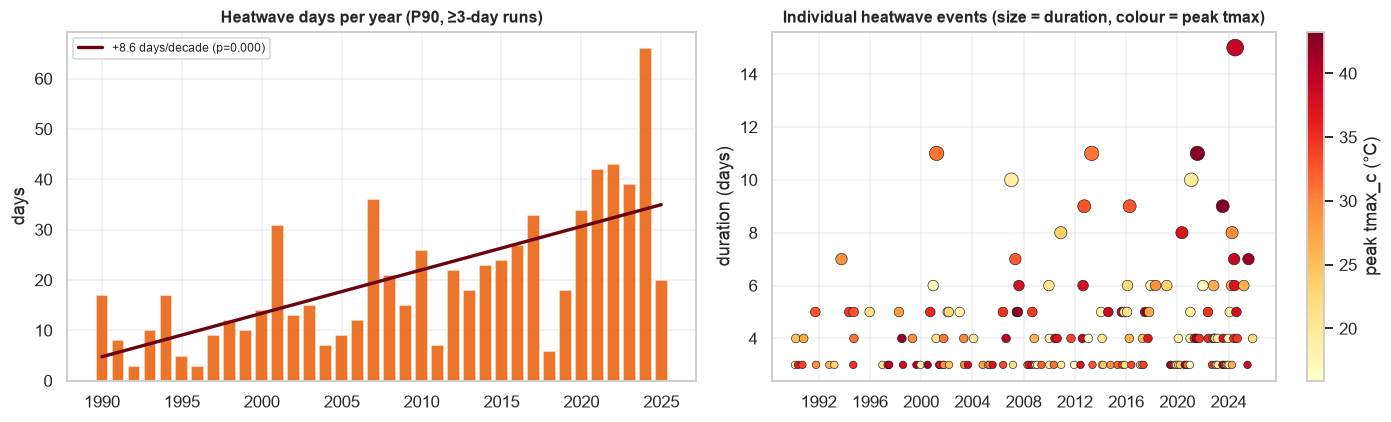

Top 10 hottest sampled days on record:


,tmax_c,tmin_c,heat_index_max_c,rh_min_percent
valid_time,,,,
2023-07-23,43.260,25.950,40.740,11.590
2021-08-02,43.020,25.190,40.690,12.150
2021-08-03,42.950,26.070,40.040,10.670
2007-07-25,42.390,24.780,40.870,14.340
2023-07-22,42.370,25.180,41.210,15.770
2007-06-26,42.250,24.890,40.020,12.760
2021-08-05,42.200,25.550,39.010,9.600
1998-07-03,42.170,27.270,41.290,16.680
2021-08-04,41.810,24.840,39.350,12.270


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(hw_year.index, hw_year["heatwave days"], color="#e85d04", alpha=0.85)
lr = stats.linregress(hw_year.index.astype(float), hw_year["heatwave days"].values)
axes[0].plot(hw_year.index, lr.intercept + lr.slope*hw_year.index, color="#6a040f", lw=2.2,
             label=f"{lr.slope*10:+.1f} days/decade (p={lr.pvalue:.3f})")
axes[0].set_title("Heatwave days per year (P90, ≥3-day runs)", fontsize=10.5)
axes[0].set_ylabel("days"); axes[0].legend(fontsize=8)

axes[1].scatter(hw["start"], hw["length"], s=hw["length"]*8,
                c=hw["peak"], cmap="YlOrRd", edgecolor="k", lw=0.4)
axes[1].set_title("Individual heatwave events (size = duration, colour = peak tmax)", fontsize=10.5)
axes[1].set_ylabel("duration (days)")
plt.colorbar(axes[1].collections[0], ax=axes[1], label="peak tmax_c (°C)")
plt.show()

print("Top 10 hottest sampled days on record:")
daily.nlargest(10, "tmax_c")[["tmax_c", "tmin_c", "heat_index_max_c", "rh_min_percent"]].round(2)

## 12. Precipitation and dry spells

All figures below use `precip_mm_scaled` (section 3.2). Multiply by 1/6 to recover the raw sampled values.

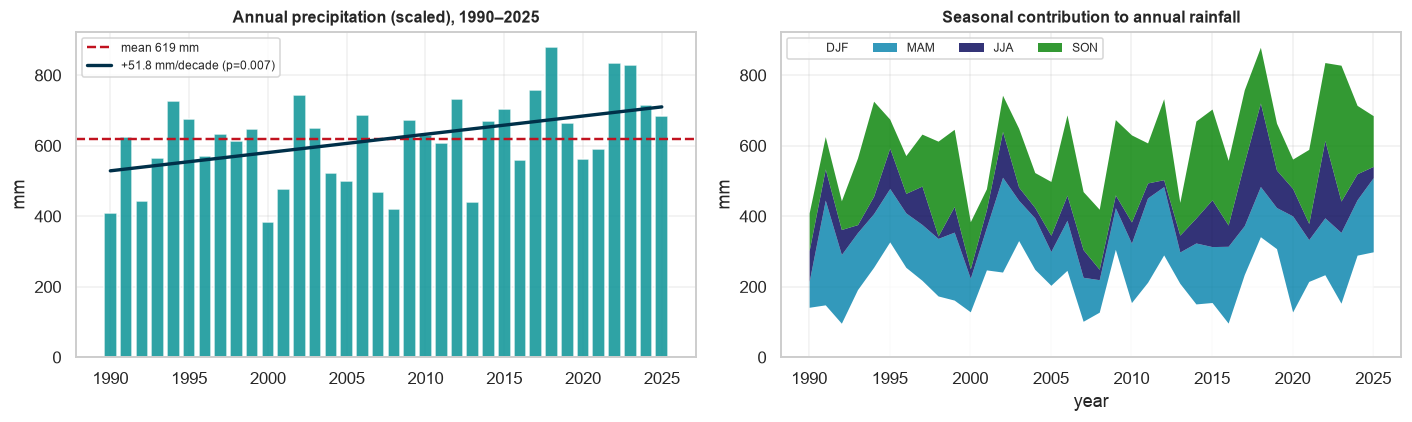

Wettest and driest years (scaled mm):


,wettest,driest
year,,
2018,879.000,NaN
2022,836.000,NaN
2023,828.000,NaN
2017,759.000,NaN
2002,743.000,NaN
2000,NaN,384.000
1990,NaN,409.000
2008,NaN,420.000
2013,NaN,439.000



Coefficient of variation of annual rainfall: 20.0%  (high interannual variability is characteristic of Mediterranean-adjacent climates)


In [43]:
ann_p_scaled = daily.groupby("year")["precip_mm_scaled"].sum()
ann_p_raw = daily.groupby("year")["precip_mm"].sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(ann_p_scaled.index, ann_p_scaled.values, color="#0a9396", alpha=0.85)
axes[0].axhline(ann_p_scaled.mean(), color="#c1121f", ls="--", lw=1.6,
                label=f"mean {ann_p_scaled.mean():.0f} mm")
lr = stats.linregress(ann_p_scaled.index.astype(float), ann_p_scaled.values)
axes[0].plot(ann_p_scaled.index, lr.intercept + lr.slope*ann_p_scaled.index,
             color="#003049", lw=2.2, label=f"{lr.slope*10:+.1f} mm/decade (p={lr.pvalue:.3f})")
axes[0].set_title("Annual precipitation (scaled), 1990–2025", fontsize=10.5)
axes[0].set_ylabel("mm"); axes[0].legend(fontsize=8)

seas_p = daily.pivot_table(index="year", columns="season", values="precip_mm_scaled", aggfunc="sum")
seas_p[SEASONS].plot(kind="area", stacked=True, ax=axes[1], alpha=0.8, colormap="ocean_r", lw=0)
axes[1].set_title("Seasonal contribution to annual rainfall", fontsize=10.5)
axes[1].set_ylabel("mm"); axes[1].legend(fontsize=8, ncol=4)
plt.show()

print("Wettest and driest years (scaled mm):")
display(pd.concat([ann_p_scaled.nlargest(5).rename("wettest"),
                   ann_p_scaled.nsmallest(5).rename("driest")], axis=1).round(0))
print(f"\nCoefficient of variation of annual rainfall: {ann_p_scaled.std()/ann_p_scaled.mean():.1%}"
      "  (high interannual variability is characteristic of Mediterranean-adjacent climates)")

Trends in precipitation characteristics:


,OLS slope/decade,OLS p-value,Theil-Sen slope/decade,Theil-Sen 95% low,Theil-Sen 95% high,Kendall tau,tau p-value,significant (p<0.05)
variable,,,,,,,,
wet days,2.907,0.100,3.274,0.000,7.143,0.250,0.034,False
mean intensity (mm/wet day),0.361,0.050,0.334,-0.083,0.718,0.187,0.108,False
max 1-day (mm),6.828,0.040,5.634,-2.111,12.717,0.156,0.182,True
P95 wet-day (mm),1.512,0.070,0.979,-0.487,2.934,0.175,0.134,False
longest dry spell (days),-2.053,0.215,-0.392,-3.333,2.105,-0.049,0.682,False


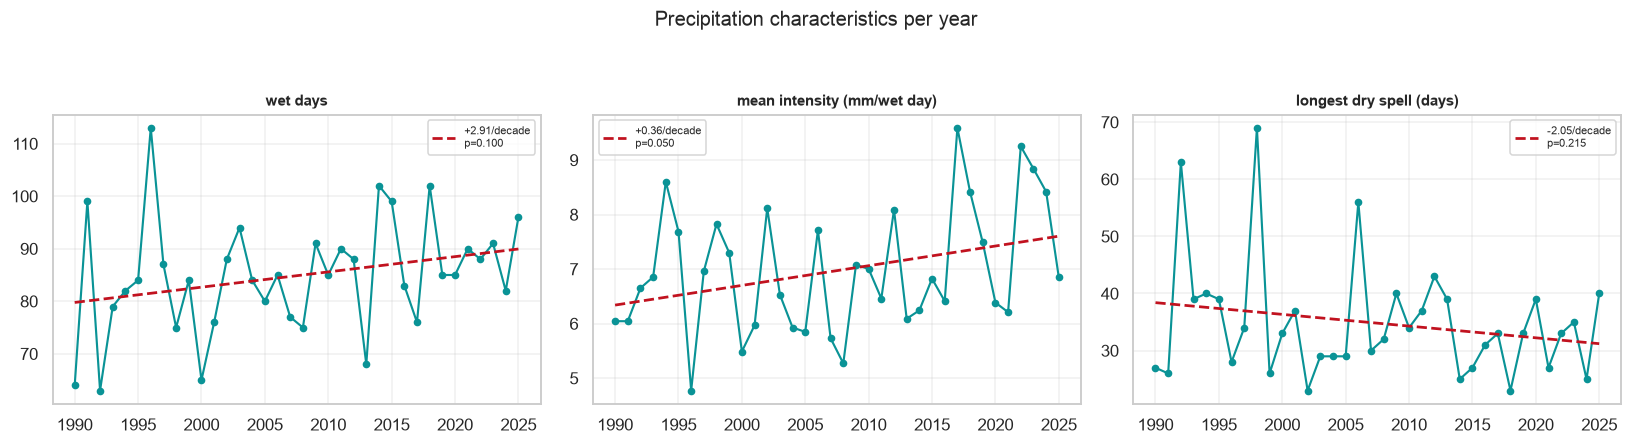

In [44]:
WET = 1.0  # mm/day threshold on the scaled series
daily["is_wet"] = daily["precip_mm_scaled"] >= WET

wetstats = pd.DataFrame({
    "wet days": daily.groupby("year")["is_wet"].sum(),
    "mean intensity (mm/wet day)": daily[daily["is_wet"]].groupby("year")["precip_mm_scaled"].mean(),
    "max 1-day (mm)": daily.groupby("year")["precip_mm_scaled"].max(),
    "P95 wet-day (mm)": daily[daily["is_wet"]].groupby("year")["precip_mm_scaled"].quantile(.95),
})


def max_dry_run(s):
    best = cur = 0
    for v in ~s.values:
        cur = cur + 1 if v else 0
        best = max(best, cur)
    return best


wetstats["longest dry spell (days)"] = daily.groupby("year")["is_wet"].apply(max_dry_run)

print("Trends in precipitation characteristics:")
display(trend_table(wetstats, list(wetstats.columns)).round(4))

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, c in zip(axes, ["wet days", "mean intensity (mm/wet day)", "longest dry spell (days)"]):
    ax.plot(wetstats.index, wetstats[c], "-o", ms=4, lw=1.4, color="#0a9396")
    lr = stats.linregress(wetstats.index.astype(float), wetstats[c].values.astype(float))
    ax.plot(wetstats.index, lr.intercept + lr.slope*wetstats.index, "--", color="#c1121f", lw=1.8,
            label=f"{lr.slope*10:+.2f}/decade\np={lr.pvalue:.3f}")
    ax.set_title(c, fontsize=9.5); ax.legend(fontsize=7.5)
fig.suptitle("Precipitation characteristics per year", y=1.06, fontsize=13)
plt.show()

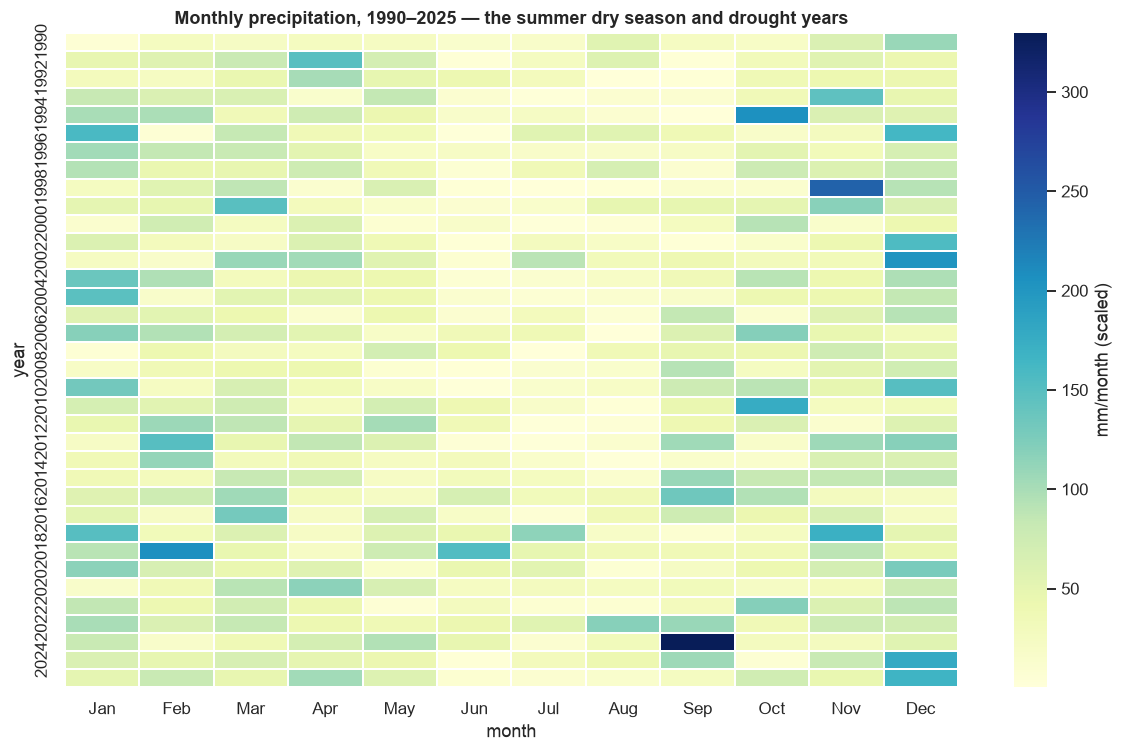

Mean Jun–Aug rainfall: 75.2 mm (12.1% of the annual total)

Monthly totals are the SPI input. Driest 6 months on record (scaled mm):


,precip_mm_scaled
valid_time,
1998-07-01,0.210
2006-08-01,0.560
1994-09-01,0.790
1992-08-01,1.020
2007-07-01,1.420
2012-07-01,2.190


In [45]:
# Monthly rainfall heatmap, straight off the monthly frame from section 6.1
piv = monthly.pivot_table(index="year", columns="month", values="precip_mm_scaled")
fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(piv, cmap="YlGnBu", ax=ax, cbar_kws={"label": "mm/month (scaled)"},
            linewidths=0.3, linecolor="white")
ax.set_xticklabels(MONTHS, rotation=0)
ax.set_title("Monthly precipitation, 1990–2025 — the summer dry season and drought years")
plt.show()

jja = piv[[6, 7, 8]].sum(axis=1).mean()
ann_tot = piv.sum(axis=1).mean()
print(f"Mean Jun–Aug rainfall: {jja:.1f} mm ({jja/ann_tot:.1%} of the annual total)")
print("\nMonthly totals are the SPI input. Driest 6 months on record (scaled mm):")
display(monthly["precip_mm_scaled"].nsmallest(6).round(2).to_frame())

## 13. Wind climatology

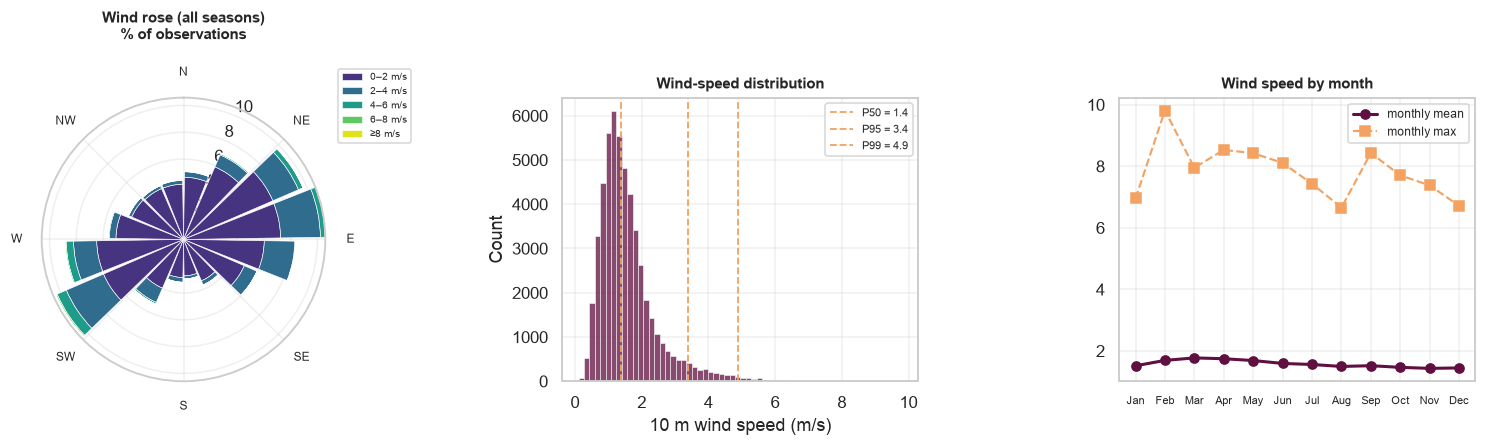

In [46]:
fig = plt.figure(figsize=(14, 4.2))

# Wind rose — direction the wind blows FROM
ax1 = fig.add_subplot(131, projection="polar")
nbins = 16
edges = np.linspace(0, 360, nbins + 1)
centers = np.deg2rad((edges[:-1] + edges[1:]) / 2)
spd_bins = [0, 2, 4, 6, 8, 100]
colors = plt.cm.viridis(np.linspace(0.15, 0.95, len(spd_bins) - 1))
bottom = np.zeros(nbins)
for i in range(len(spd_bins) - 1):
    sub = lar[(lar["wind_speed"] >= spd_bins[i]) & (lar["wind_speed"] < spd_bins[i+1])]
    counts, _ = np.histogram(sub["wind_dir"], bins=edges)
    frac = counts / len(lar) * 100
    lbl = f"{spd_bins[i]}–{spd_bins[i+1]} m/s" if i < len(spd_bins)-2 else f"≥{spd_bins[i]} m/s"
    ax1.bar(centers, frac, width=2*np.pi/nbins*0.92, bottom=bottom,
            color=colors[i], edgecolor="white", lw=0.4, label=lbl)
    bottom += frac
ax1.set_theta_zero_location("N"); ax1.set_theta_direction(-1)
ax1.set_xticks(np.deg2rad(np.arange(0, 360, 45)))
ax1.set_xticklabels(["N","NE","E","SE","S","SW","W","NW"], fontsize=8)
ax1.set_title("Wind rose (all seasons)\n% of observations", fontsize=10, pad=18)
ax1.legend(loc="upper right", bbox_to_anchor=(1.32, 1.12), fontsize=6.5)
ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(132)
sns.histplot(lar["wind_speed"], bins=60, ax=ax2, color="#5f0f40", edgecolor=None)
for q in (0.5, 0.95, 0.99):
    ax2.axvline(lar["wind_speed"].quantile(q), ls="--", lw=1.2, color="#f4a261",
                label=f"P{int(q*100)} = {lar['wind_speed'].quantile(q):.1f}")
ax2.set_xlabel(LABELS["wind_speed"]); ax2.set_title("Wind-speed distribution", fontsize=10)
ax2.legend(fontsize=7.5)

ax3 = fig.add_subplot(133)
mw = lar.groupby("month")["wind_speed"].agg(["mean", "max"])
ax3.plot(mw.index, mw["mean"], "o-", color="#5f0f40", lw=2, label="monthly mean")
ax3.plot(mw.index, mw["max"], "s--", color="#f4a261", lw=1.4, label="monthly max")
ax3.set_xticks(range(1, 13)); ax3.set_xticklabels(MONTHS, fontsize=7.5)
ax3.set_title("Wind speed by month", fontsize=10); ax3.legend(fontsize=8)
plt.show()

In [47]:
SECTORS = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]
lar["sector"] = pd.cut((lar["wind_dir"] + 22.5) % 360, bins=np.arange(0, 361, 45),
                       labels=SECTORS, include_lowest=True)

freq = (pd.crosstab(lar["season"], lar["sector"], normalize="index")
          .reindex(SEASONS)[SECTORS] * 100).round(1)
print("Frequency of each 45° direction sector by season (%):")
display(freq)
print("\nPrevailing direction by season:", freq.idxmax(axis=1).to_dict())

Frequency of each 45° direction sector by season (%):


sector,N,NE,E,SE,S,SW,W,NW
season,,,,,,,,
DJF,12.300,17.300,12.200,6.400,8.200,19.500,13.400,10.600
MAM,6.500,15.600,19.000,9.600,6.200,20.700,16.400,6.100
JJA,8.800,16.000,23.900,13.700,4.300,8.300,15.500,9.500
SON,10.500,18.000,20.600,8.900,5.900,14.100,12.600,9.300



Prevailing direction by season: {'DJF': 'SW', 'MAM': 'SW', 'JJA': 'E', 'SON': 'E'}


## 14. Inter-variable relationships

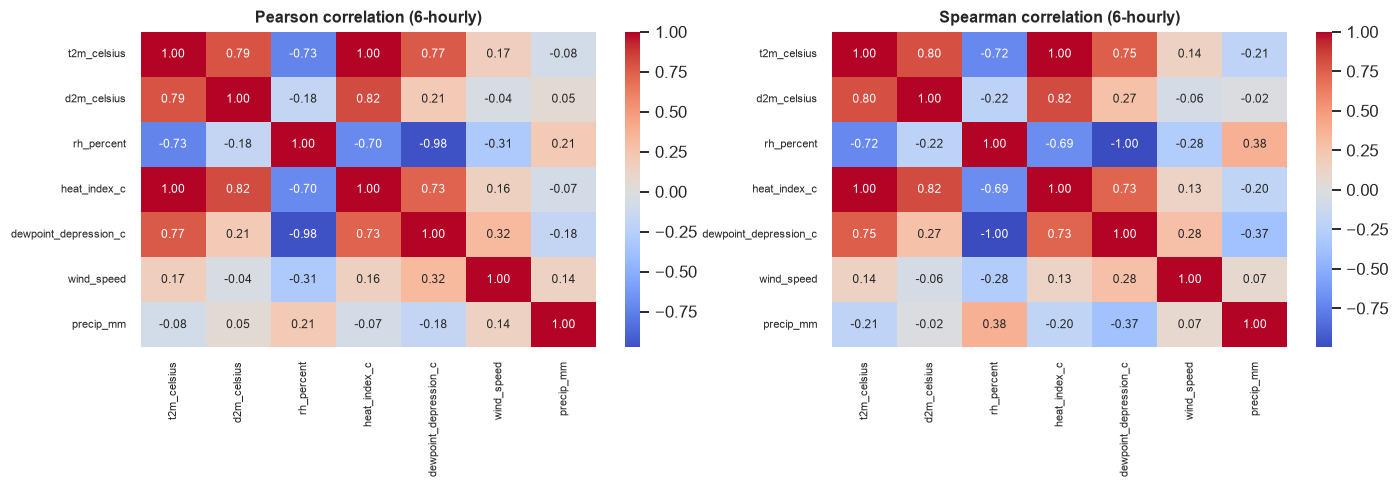

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
sns.heatmap(lar[ANALYSIS].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            ax=axes[0], annot_kws={"size": 8})
axes[0].set_title("Pearson correlation (6-hourly)", fontsize=10.5)
sns.heatmap(lar[ANALYSIS].corr(method="spearman"), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=axes[1], annot_kws={"size": 8})
axes[1].set_title("Spearman correlation (6-hourly)", fontsize=10.5)
for ax in axes:
    ax.tick_params(labelsize=7)
plt.show()

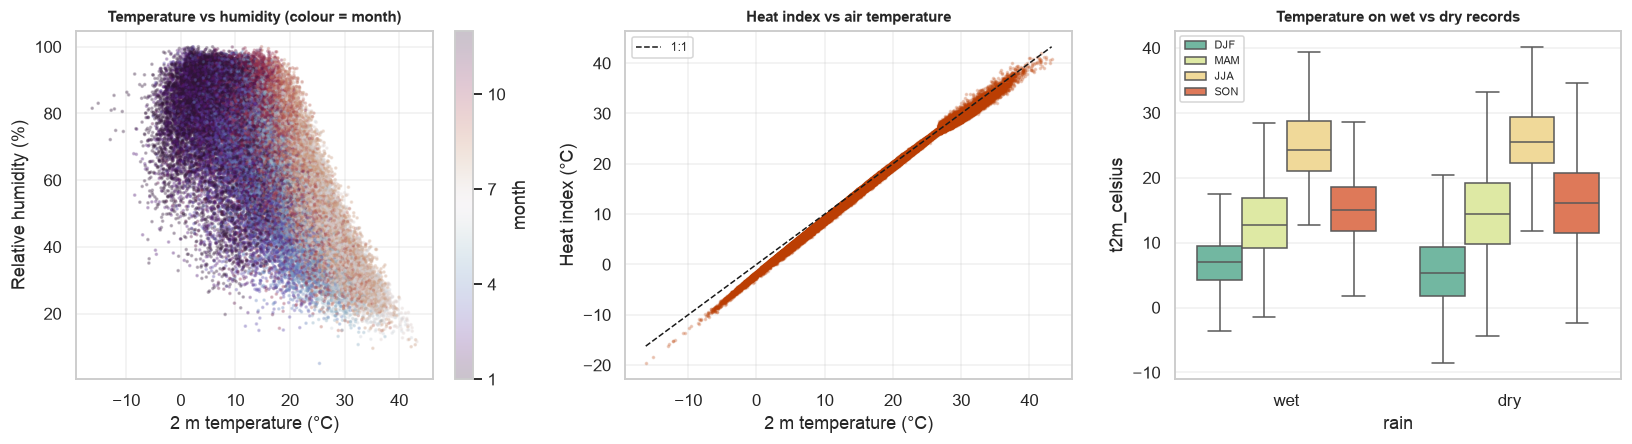

Heat-index amplification above 30 °C air temperature:
  mean heat index − air temp = -0.73 °C
  max  heat index − air temp = +3.05 °C
  A negative or small gap indicates dry-heat summers, where evaporative cooling keeps the
  heat index from amplifying much above the air temperature — plausible for an inland plain.


In [49]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
sc = axes[0].scatter(lar["t2m_celsius"], lar["rh_percent"], c=lar["month"],
                     cmap="twilight_shifted", s=2, alpha=0.25)
axes[0].set_xlabel(LABELS["t2m_celsius"]); axes[0].set_ylabel(LABELS["rh_percent"])
axes[0].set_title("Temperature vs humidity (colour = month)", fontsize=10)
plt.colorbar(sc, ax=axes[0], label="month", ticks=[1, 4, 7, 10])

axes[1].scatter(lar["t2m_celsius"], lar["heat_index_c"], s=2, alpha=0.2, color="#bb3e03")
lim = [lar["t2m_celsius"].min(), lar["t2m_celsius"].max()]
axes[1].plot(lim, lim, "k--", lw=1, label="1:1")
axes[1].set_xlabel(LABELS["t2m_celsius"]); axes[1].set_ylabel(LABELS["heat_index_c"])
axes[1].set_title("Heat index vs air temperature", fontsize=10); axes[1].legend(fontsize=8)

sns.boxplot(data=lar.assign(rain=np.where(lar["precip_mm"] > 0.01, "wet", "dry")),
            x="rain", y="t2m_celsius", hue="season", hue_order=SEASONS, ax=axes[2],
            showfliers=False, palette="Spectral_r")
axes[2].set_title("Temperature on wet vs dry records", fontsize=10)
axes[2].legend(fontsize=7, title=None)
plt.show()

hot_rec = lar[lar["t2m_celsius"] >= 30]
hi_gap = (hot_rec["heat_index_c"] - hot_rec["t2m_celsius"]).mean()
print("Heat-index amplification above 30 °C air temperature:")
print(f"  mean heat index − air temp = {hi_gap:+.2f} °C")
print(f"  max  heat index − air temp = {(hot_rec['heat_index_c']-hot_rec['t2m_celsius']).max():+.2f} °C")
print("  A negative or small gap indicates dry-heat summers, where evaporative cooling keeps the")
print("  heat index from amplifying much above the air temperature — plausible for an inland plain.")

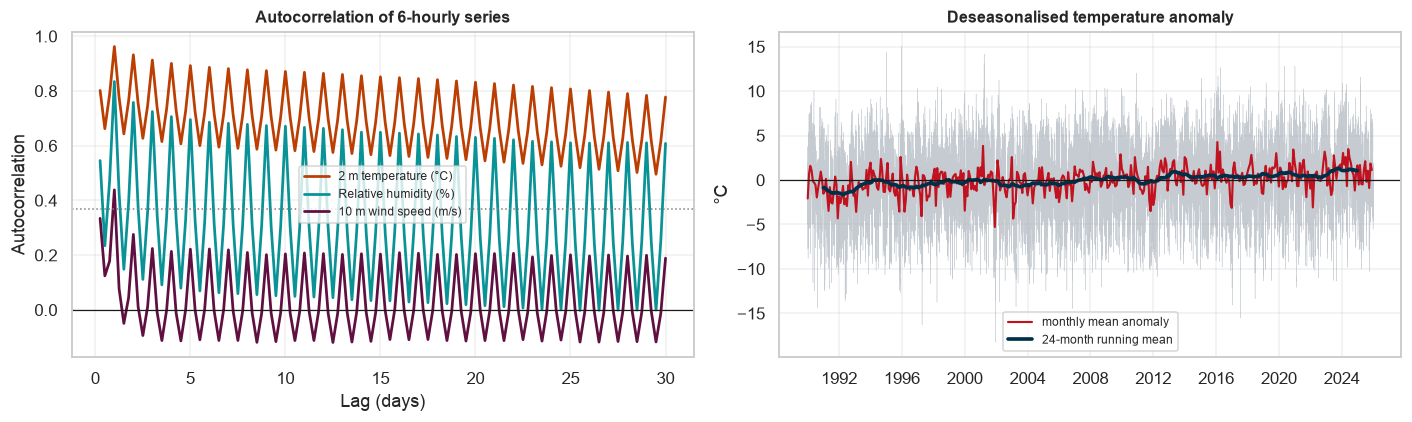

Variance explained by the seasonal+diurnal climatology: 87.1%


In [50]:
# Autocorrelation and the deseasonalised anomaly — both relevant to any forecasting model
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
lags = np.arange(1, 121)   # 1..120 six-hourly steps = up to 30 days
for v, c in [("t2m_celsius", "#bb3e03"), ("rh_percent", "#0a9396"), ("wind_speed", "#5f0f40")]:
    axes[0].plot(lags/4, [lar[v].autocorr(l) for l in lags], lw=1.8, color=c, label=LABELS[v])
axes[0].axhline(0, color="k", lw=0.8); axes[0].axhline(1/np.e, color="grey", ls=":", lw=1)
axes[0].set_xlabel("Lag (days)"); axes[0].set_ylabel("Autocorrelation")
axes[0].set_title("Autocorrelation of 6-hourly series", fontsize=10.5)
axes[0].legend(fontsize=8)

clim = lar.groupby([lar.index.dayofyear, lar["hour"]])["t2m_celsius"].transform("mean")
lar["t2m_anom"] = lar["t2m_celsius"] - clim
axes[1].plot(lar.index, lar["t2m_anom"], lw=0.25, color="#adb5bd", alpha=0.7)
mth = lar["t2m_anom"].resample("MS").mean()
axes[1].plot(mth.index, mth.values, lw=1.4, color="#c1121f", label="monthly mean anomaly")
axes[1].plot(mth.index, mth.rolling(24, center=True).mean(), lw=2.4, color="#003049",
             label="24-month running mean")
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_title("Deseasonalised temperature anomaly", fontsize=10.5)
axes[1].set_ylabel("°C"); axes[1].legend(fontsize=8)
plt.show()

var_expl = 1 - lar["t2m_anom"].var() / lar["t2m_celsius"].var()
print(f"Variance explained by the seasonal+diurnal climatology: {var_expl:.1%}")

## 15. Key findings and exported summaries

In [51]:
lr_t  = stats.linregress(annual.index.astype(float), annual["t2m_mean"].values)
lr_hw = stats.linregress(hw_year.index.astype(float), hw_year["heatwave days"].values)
lr_p  = stats.linregress(ann_p_scaled.index.astype(float), ann_p_scaled.values)
tr35  = trend_table(hot, ["days tmax≥35°C"]).iloc[0]["OLS slope/decade"]
tr_tn = trend_table(hot, ["tropical nights tmin≥20°C"]).iloc[0]["OLS slope/decade"]

L = []
A = L.append
A("=" * 78)
A("EDA SUMMARY - ERA5 LARISSA, 1990-2025".center(78))
A("=" * 78)
A("")
A("DATA INTEGRITY")
A(f"  {len(raw):,} rows = {qc['unique_timestamps']:,} timestamps x {qc['grid_points']} grid points (2x2 grid)")
A(f"  Missing values ......... {qc['missing_values_total']}")
A(f"  Duplicate rows ......... {qc['duplicate_rows']}")
A(f"  Missing timestamps ..... {qc['missing_timestamps']} (strict 6-hourly grid, no gaps)")
A(f"  Constant columns ....... {const_cols} -> dropped")
A(f"  Sampling hours ......... {sorted(int(h) for h in raw['valid_time'].dt.hour.unique())} - request confirmed")
A("")
A("TWO SAMPLING CAVEATS")
A(f"  1. 6-hourly sampling: apparent daily range is {daily['dtr_c'].mean():.1f} °C,")
A("     so tmax_c / tmin_c are biased inward. Fine for trends, not absolute extremes.")
A(f"  2. `tp` is an HOURLY accumulation sampled 4x/day: summing gives {ann_p_raw.mean():.0f} mm/yr")
A(f"     vs a rough ~400-450 mm/yr cited regional normal (unconfirmed, see section 3.2). precip_mm_scaled (x6) gives {ann_p_scaled.mean():.0f} mm/yr —")
A("     above that range, an open discrepancy rather than a validated total.")
A("")
A("PIPELINE")
A(f"  {len(raw):,} raw rows -> groupby(valid_time).mean() -> {len(lar):,} six-hourly Larissa rows")
A(f"  -> resample('D') -> {len(daily):,} daily rows -> resample('MS') -> {len(monthly)} monthly rows")
A(f"  Grid points are near-interchangeable for temperature (mean r = {r_t:.4f}, spread in")
A(f"  point means {(spread.max()-spread.min())['t2m_celsius']:.2f} °C); precipitation less so (mean r = {r_p:.3f}).")
A("")
A("CLIMATOLOGY")
A(f"  Annual mean temperature ... {lar['t2m_celsius'].mean():.2f} °C")
A(f"  Hottest month ............. {MONTHS[mon['t2m_celsius'].idxmax()-1]} ({mon['t2m_celsius'].max():.1f} °C)")
A(f"  Coldest month ............. {MONTHS[mon['t2m_celsius'].idxmin()-1]} ({mon['t2m_celsius'].min():.1f} °C)")
A(f"  Annual amplitude .......... {mon['t2m_celsius'].max()-mon['t2m_celsius'].min():.1f} °C")
A(f"  Mean daily tmax / tmin .... {daily['tmax_c'].mean():.1f} / {daily['tmin_c'].mean():.1f} °C")
A(f"  Mean relative humidity .... {lar['rh_percent'].mean():.1f} % (monthly range {mon['rh_percent'].min():.0f}-{mon['rh_percent'].max():.0f} %)")
A(f"  Mean wind speed ........... {lar['wind_speed'].mean():.2f} m/s")
A(f"  Rainfall (scaled) ......... {ann_p_scaled.mean():.0f} mm/yr, CV {ann_p_scaled.std()/ann_p_scaled.mean():.0%}")
A(f"  Jun-Aug rainfall .......... {jja:.0f} mm ({jja/ann_tot:.0%} of the annual total)")
A(f"  Seasonal+diurnal cycle explains {var_expl:.0%} of temperature variance")
A("")
A("TRENDS 1990-2025 (per decade; 36 years is short, so read p-values carefully)")
A(f"  Mean temperature .......... {lr_t.slope*10:+.2f} °C   (p = {lr_t.pvalue:.4f})")
A(f"  Daily tmax mean ........... {trends.loc['tmax_mean','OLS slope/decade']:+.2f} °C   (p = {trends.loc['tmax_mean','OLS p-value']:.4f})")
A(f"  Daily tmin mean ........... {trends.loc['tmin_mean','OLS slope/decade']:+.2f} °C   (p = {trends.loc['tmin_mean','OLS p-value']:.4f})")
A(f"  Warm tail (P95) ........... {trends.loc['t2m_p95','OLS slope/decade']:+.2f} °C   (p = {trends.loc['t2m_p95','OLS p-value']:.4f})")
A(f"  Cold tail (P05) ........... {trends.loc['t2m_p05','OLS slope/decade']:+.2f} °C   (p = {trends.loc['t2m_p05','OLS p-value']:.4f})")
A(f"  Relative humidity ......... {trends.loc['rh_mean','OLS slope/decade']:+.2f} %    (p = {trends.loc['rh_mean','OLS p-value']:.4f})")
A(f"  Dewpoint depression ....... {trends.loc['dpd_mean','OLS slope/decade']:+.2f} °C   (p = {trends.loc['dpd_mean','OLS p-value']:.4f})")
A(f"  Wind speed ................ {trends.loc['wind_mean','OLS slope/decade']:+.3f} m/s (p = {trends.loc['wind_mean','OLS p-value']:.4f})")
A(f"  Annual rainfall (scaled) .. {lr_p.slope*10:+.1f} mm  (p = {lr_p.pvalue:.4f})")
A(f"  Fastest-warming season .... {seas_tr['OLS slope/decade'].idxmax()} ({seas_tr['OLS slope/decade'].max():+.2f} °C/decade)")
A("")
A("EXTREMES")
A(f"  Heatwaves (P90, >=3 days) . {len(hw)} events, {lr_hw.slope*10:+.1f} heatwave days/decade (p = {lr_hw.pvalue:.4f})")
A(f"  Longest heatwave .......... {int(hw['length'].max())} days from {hw.loc[hw['length'].idxmax(),'start']:%Y-%m-%d}")
A(f"  Hottest sampled day ....... {daily['tmax_c'].max():.1f} °C on {daily['tmax_c'].idxmax():%Y-%m-%d}")
A(f"  Days tmax>=35 °C .......... {hot['days tmax≥35°C'].mean():.0f}/yr mean, trend {tr35:+.1f}/decade")
A(f"  Tropical nights >=20 °C ... {hot['tropical nights tmin≥20°C'].mean():.0f}/yr mean, trend {tr_tn:+.1f}/decade")
A(f"  Longest dry spell ......... {int(wetstats['longest dry spell (days)'].max())} days ({wetstats['longest dry spell (days)'].idxmax()})")
A(f"  Heat index - air temp ..... {hi_gap:+.1f} °C when T>=30 °C")
A("=" * 78)

print("\n".join(L))

                    EDA SUMMARY - ERA5 LARISSA, 1990-2025                     

DATA INTEGRITY
  210,384 rows = 52,596 timestamps x 4 grid points (2x2 grid)
  Missing values ......... 0
  Duplicate rows ......... 0
  Missing timestamps ..... 0 (strict 6-hourly grid, no gaps)
  Constant columns ....... [] -> dropped
  Sampling hours ......... [0, 6, 12, 18] - request confirmed

TWO SAMPLING CAVEATS
  1. 6-hourly sampling: apparent daily range is 9.5 °C,
     so tmax_c / tmin_c are biased inward. Fine for trends, not absolute extremes.
  2. `tp` is an HOURLY accumulation sampled 4x/day: summing gives 103 mm/yr
     vs a rough ~400-450 mm/yr cited regional normal (unconfirmed, see section 3.2). precip_mm_scaled (x6) gives 619 mm/yr —
     above that range, an open discrepancy rather than a validated total.

PIPELINE
  210,384 raw rows -> groupby(valid_time).mean() -> 52,596 six-hourly Larissa rows
  -> resample('D') -> 13,149 daily rows -> resample('MS') -> 432 monthly rows
  Grid points 

In [52]:
exports = {
    "larissa_6hourly.csv":       lar.drop(columns=["sector"], errors="ignore"),
    "larissa_daily.csv":         daily,
    "larissa_monthly.csv":       monthly,
    "annual_summary.csv":        annual.join(hot).join(hw_year).join(wetstats),
    "monthly_climatology.csv":   mon,
    "trends.csv":                trends,
    "seasonal_trends.csv":       seas_tr,
    "heatwave_events.csv":       hw.reset_index(drop=True),
    "per_grid_point_stats.csv":  by_point,
}
for name, obj in exports.items():
    obj.to_csv(OUT / name)
    print(f"wrote {OUT/name}  ({obj.shape[0]} rows x {obj.shape[1]} cols)")

print("\nThe three frames the rest of the capstone needs:")
print("  larissa_6hourly.csv  — averaged across grid points, all derived variables")
print("  larissa_daily.csv    — tmax_c / tmin_c / precip_mm_scaled, ready for heatwave analysis")
print("  larissa_monthly.csv  — precip_mm_scaled, ready for SPI")

wrote ../eda_outputs/larissa/larissa_6hourly.csv  (52596 rows x 20 cols)
wrote ../eda_outputs/larissa/larissa_daily.csv  (13149 rows x 16 cols)
wrote ../eda_outputs/larissa/larissa_monthly.csv  (432 rows x 10 cols)
wrote ../eda_outputs/larissa/annual_summary.csv  (36 rows x 26 cols)
wrote ../eda_outputs/larissa/monthly_climatology.csv  (12 rows x 7 cols)
wrote ../eda_outputs/larissa/trends.csv  (11 rows x 8 cols)
wrote ../eda_outputs/larissa/seasonal_trends.csv  (4 rows x 8 cols)
wrote ../eda_outputs/larissa/heatwave_events.csv  (163 rows x 5 cols)
wrote ../eda_outputs/larissa/per_grid_point_stats.csv  (4 rows x 14 cols)

The three frames the rest of the capstone needs:
  larissa_6hourly.csv  — averaged across grid points, all derived variables
  larissa_daily.csv    — tmax_c / tmin_c / precip_mm_scaled, ready for heatwave analysis
  larissa_monthly.csv  — precip_mm_scaled, ready for SPI


## 16. Raw time series sanity check

This follows the Week-1 plan's Day-7 checklist item: convert `t2m` and `tp` straight off the raw grid
(no unit conversion, no grid-averaging beyond a simple `mean(dim=['latitude', 'longitude'])`, no resampling)
into a pandas Series and look at it. The point is to catch a broken download or a silently missing chunk of
time *before* trusting any of the derived climatology above — so this deliberately re-derives the plot from
`raw` rather than from `lar`, to sanity-check the same raw grid data section 1.4 originally loaded, now
extended through 2025.

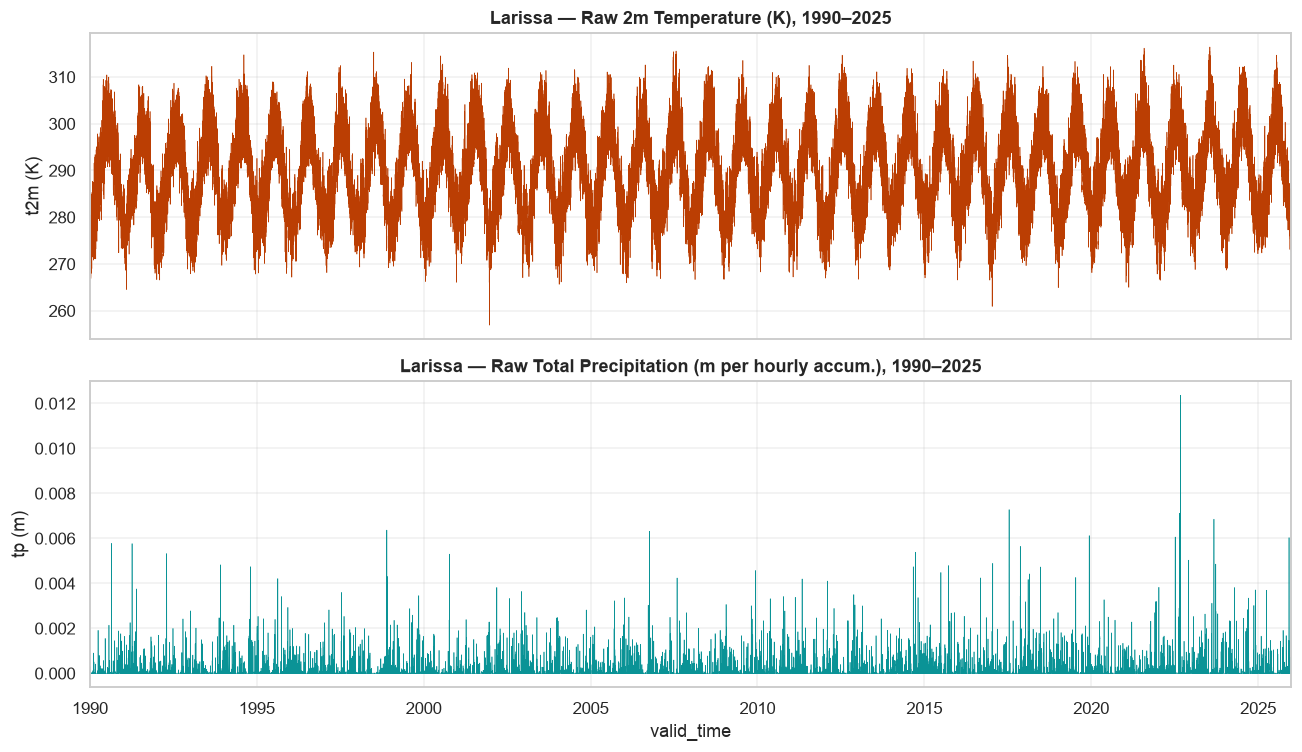

Series length: 52,596 points, 1990-01-01 -> 2025-12-31
t2m range: 256.9 - 316.4 K (-16.2 to 43.3 °C)
tp range: 0.00000 - 0.01236 m per 6-hourly accumulation
Any NaNs in the reconstructed grid: t2m=0, tp=0


In [53]:
ds_larissa = raw.set_index(["valid_time", "latitude", "longitude"])[["t2m", "tp"]].to_xarray()

raw_temp_series = ds_larissa["t2m"].mean(dim=["latitude", "longitude"]).to_series()
raw_precip_series = ds_larissa["tp"].mean(dim=["latitude", "longitude"]).to_series()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
raw_temp_series.plot(ax=axes[0], linewidth=0.4, color="#bb3e03")
axes[0].set_title("Larissa — Raw 2m Temperature (K), 1990–2025")
axes[0].set_ylabel("t2m (K)")

raw_precip_series.plot(ax=axes[1], linewidth=0.4, color="#0a9396")
axes[1].set_title("Larissa — Raw Total Precipitation (m per hourly accum.), 1990–2025")
axes[1].set_ylabel("tp (m)")
plt.tight_layout()
plt.savefig(OUT / "larissa_temp_precip_check.png")
plt.show()

print(f"Series length: {len(raw_temp_series):,} points, "
      f"{raw_temp_series.index.min():%Y-%m-%d} -> {raw_temp_series.index.max():%Y-%m-%d}")
print(f"t2m range: {raw_temp_series.min():.1f} - {raw_temp_series.max():.1f} K "
      f"({raw_temp_series.min()-273.15:.1f} to {raw_temp_series.max()-273.15:.1f} °C)")
print(f"tp range: {raw_precip_series.min():.5f} - {raw_precip_series.max():.5f} m per 6-hourly accumulation")
print(f"Any NaNs in the reconstructed grid: t2m={int(raw_temp_series.isna().sum())}, "
      f"tp={int(raw_precip_series.isna().sum())}")

### 16.1 What this shows

The raw 1990–2025 series is visually continuous in both panels — no flat stretches, dropouts, or
obviously mismatched chunks anywhere along the 36-year axis, and the printed check above confirms zero
NaNs across 52,596 six-hourly points. Temperature traces a clean, regular seasonal sawtooth spanning
roughly 257–316 K (-16 °C to 43 °C), consistent with the inland, semi-continental character (cold winter
nights, hot summer days) established in section 8. Precipitation is sparse and spiky, as expected for raw
hourly-accumulation data with a low base rate; spike density and magnitude look stable across the full
record, with no era where activity conspicuously vanishes or the spikes change character — no visual
reason to suspect a broken download or a silently missing chunk of time.

## 17. Key findings, independent of the project hypotheses

Everything below is what the ERA5 record (plus the SPI-3/volatility work in section 10.4) shows,
with hypothesis framing stripped out — pulled directly from this notebook's executed output,
1990–2025.

### The headline: warming here is broad and comprehensive — day, night, and every season

Unlike Seville's asymmetric pattern (see `seville_era5_eda.ipynb`), Larissa's warming signal shows
up almost everywhere it's tested:

| Metric | Slope/decade | p-value | Significant? |
|---|---|---|---|
| `t2m_mean` (overall mean) | **+0.50°C** | **<0.0001** | Yes |
| `tmax_mean` (daily max) | +0.63°C | <0.0001 | Yes |
| **`tmin_mean` (daily min)** | **+0.42°C** | **<0.0001** | **Yes — nights are warming here** |
| `t2m_p95` (warm tail) | +0.65°C | <0.0001 | Yes |
| `t2m_p05` (cold tail) | +0.45°C | 0.0124 | Yes |
| `rh_mean` | −0.99%/decade | 0.0096 | Yes — humidity dropping |
| `dpd_mean` (dewpoint depression) | +0.32°C | 0.0033 | Yes |
| `wind_mean` | +0.01 m/s | 0.289 | No |
| `precip_scaled` | **+51.8 mm** | **0.0071** | **Yes — rainfall increasing** |

Nine of ten metrics tested are significant. Warm tail, cold tail, day, and night are all moving
together and all clear conventional significance — a different shape from a typical "average
creeps up while extremes stay noisy" pattern.

### Every season shows a significant warming trend — all four

| Season | Slope/decade | p-value |
|---|---|---|
| DJF (winter) | +0.55°C | 0.001 |
| MAM (spring) | +0.45°C | 0.004 |
| JJA (summer) | +0.62°C | <0.0001 |
| SON (autumn) | +0.38°C | 0.003 |

Summer warms fastest, but nothing here is a lone outlier — all four seasons independently clear
p<0.05.

### Extreme-heat counts: significant at every single threshold tested

| Threshold | Slope/decade | p-value |
|---|---|---|
| Days tmax≥30°C | +8.4 days | <0.0001 |
| Days tmax≥33°C | +10.0 days | <0.0001 |
| Days tmax≥35°C | +6.2 days | <0.0001 |
| Days tmax≥37°C | +3.1 days | 0.001 |
| Days tmax≥40°C | +0.7 days | 0.040 |
| Heatwaves (P90, ≥3 days) | +8.6 days | <0.0001 |
| **Tropical nights (tmin≥20°C)** | **+8.3 days** | **<0.0001** |

163 heatwave events total, longest streak 15 days (starting 2024-07-08), hottest sampled day
43.3°C (2023-07-23). Every threshold from the mildest to the most extreme is significant.

### Precipitation is intensifying, and if anything trending wetter overall — not drying

| Metric | OLS p | Kendall τ p |
|---|---|---|
| Wet days/year | 0.100 | **0.034** |
| Mean wet-day intensity | 0.050 | 0.108 |
| Max 1-day rainfall | **0.040** | 0.182 |
| P95 wet-day amount | 0.070 | 0.134 |
| Longest dry spell | 0.215 (slope **−2.05/decade**) | 0.682 |

A mixed picture depending on which test is read, but nothing points toward drying: annual total
rainfall is up significantly (+51.8 mm/decade, see the headline table), and the longest-dry-spell
point estimate trends *shorter*, not longer. Longest dry spell on record: 69 days (1998).

### SPI-3 / volatility (section 10.4, computed in `Calculating_SPI_for_Larissa.ipynb`)

- `min_spi3` (each year's worst drought depth): +0.183/decade, p=0.061 — trending *milder*, not
  more severe.
- `max_week_precip_mm` (flood intensity): +12.6 mm/decade, OLS p=0.055, but **Kendall τ p=0.021** —
  the outlier-robust test finds this significant.
- September 2023 (Storm Daniel): SPI-3 hit **+3.49**, an extreme wet outlier — but the months
  leading into it were only mildly dry (minimum −0.94 in April) and had already recovered to wet
  (+0.84 to +1.68) by May–August. No severe drought preceded the flood.
- SPI-3's own implementation check passed exactly: mean 0.000, std 1.001 over its 1990–2020
  reference period.

### Other findings

- **Decadal step-up**: 15.02°C (1990s) → 15.38 → 15.98 → 16.32°C (2020s, 6 years so far) — a
  steady, monotonic rise across all four decades.
- **Dry heat, same as Seville**: heat index sits below air temperature above 30°C (mean −0.7°C).
- **Grid validity**: temperature nearly interchangeable across the four grid points (r=0.992),
  precipitation less so (r=0.728) — same pattern as Seville, averaging is more defensible for
  temperature than rainfall.
- **Data integrity**: 210,384 rows, zero missing values, zero duplicates, gap-free 6-hourly grid
  across all 36 years.
- **One open item, not yet resolved**: raw annual precipitation (619 mm/yr scaled) sits above the
  ~400–450 mm/yr regional normal cited in section 3.2 — flagged there as an unconfirmed
  discrepancy, not an error, but worth checking against an independent source before treating
  619 mm/yr as validated.

### Suggested next steps

1. ~~Compute SPI~~ — done: SPI-3 is computed in `Calculating_SPI_for_Larissa.ipynb` (gamma fit per
   calendar month on the fixed 1990–2020 reference period, using the monthly frame from section 6.1),
   and its trend is fitted alongside the `min_spi3` / `max_week_precip_mm` volatility metric in
   section 10.4 above.
2. **Re-download the full hourly ERA5 series** if absolute precipitation totals or true daily temperature
   extremes matter. The trends and relative patterns here hold; the absolute magnitudes of `tp`, `tmax_c`,
   and `tmin_c` do not.
3. **Cross-check against station data** — a long-running Larissa airport or agrometeorological station record
   would let you bias-correct the ERA5 grid averages, the way Seville Airport (WMO 08391) does for Seville.
4. **Attribute the interannual variability** by regressing the deseasonalised anomaly against circulation
   indices (NAO, and Mediterranean-specific indices), which drive much of the region's rainfall variability.
5. **Keep extending the record** — this dataset now runs through 2025 (1990–2020 original pull +
   2021–2025 extension, see `extend_data_2021_2025.py`). Repeating that pattern annually keeps the
   trend estimates current as new ERA5 years become available.
6. **Compare directly against Seville** — both notebooks now share an identical pipeline and export schema
   (`*_6hourly.csv`, `*_daily.csv`, `*_monthly.csv`), so the two cities can be merged and contrasted directly:
   inland-continental Larissa vs. coastal-Mediterranean Seville.